# Example notebook for optimize module

In the following we exemplify how to utilize the optimize module of pyMOE which uses gradient descent methods for inverse design of masks. 

The idea is that the mask pixels can be iteratively changed to minimize of a loss function which evaluates the simulated propagated field from the mask against a target response. A gradient descent method changes the mask pixels iteratively in the direction of the gradient until a certain tolerance is met. Some metrics can be used for loss function constructions. Examples of simple loss functions are the root mean square error (RMSE) or the maximum likelihood estimator. pyMOE optimize module calculates the gradient through JAX package, employing scipy or optax (JAX) optimization frameworks, being extremelly versatile, allowing the user to pick different propagation methods for the task.    

Further documentation will be updated in future releases 

In [1]:
# Notebook display options, change as your preference/system
%matplotlib inline
%config InlineBackend.print_figure_kwargs={'facecolor' : "w",'bbox_inches':None}

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 120

In [2]:
# Notebook display options, change as your preference/syste

import sys
sys.path.insert(0,'..')
sys.path.insert(0,'../..')

from matplotlib import pyplot as plt 
import numpy as np 

from scipy.constants import micro, nano, milli

import pyMOE as moe 
from pyMOE.generate import *  
from pyMOE.propagate import * 
from pyMOE.metrics import * 
from pyMOE.optimizer import * 
from pyMOE.ensemble import * 

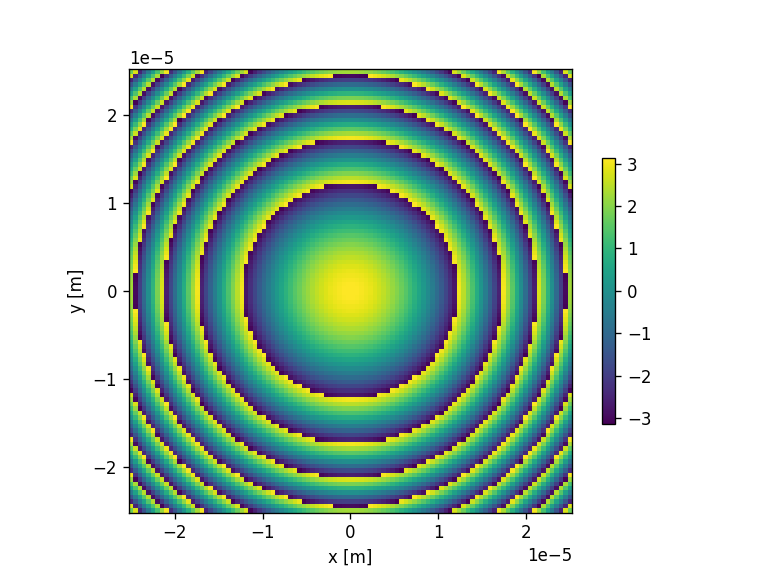

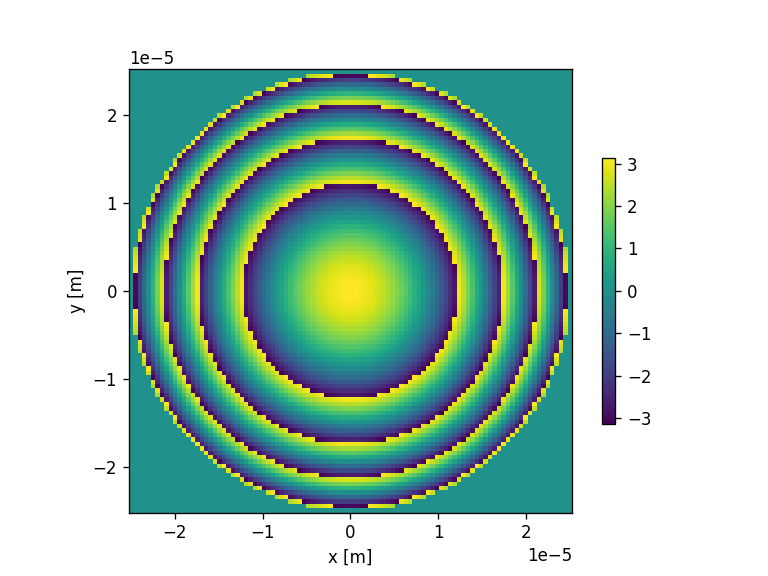

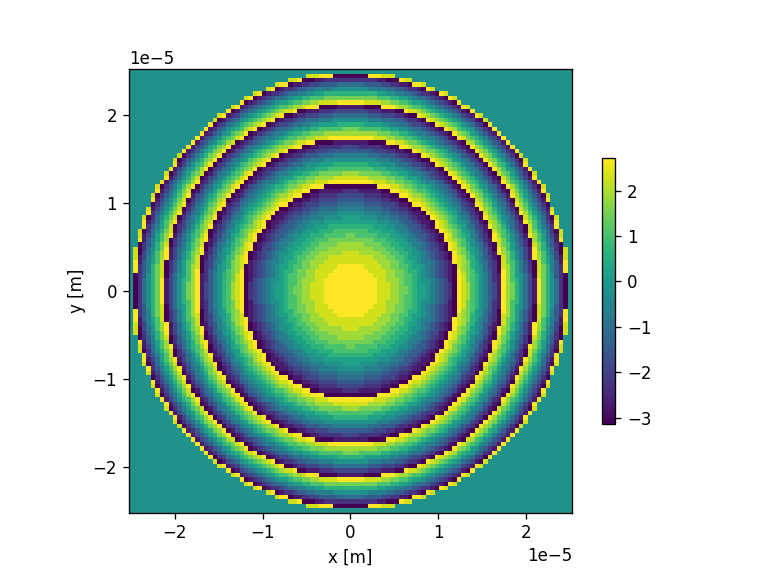

In [3]:
# First just for initialization purpose we will initalize a Fresnel lens 

#number of pixels 
x_pixel = 100
y_pixel = 100

#size of the rectangular mask 
aperture_width  = 50e-6 #m
aperture_height = 50e-6

pixsize = 1e-6 #m

wavelength = 500e-9 #m
focal_length = 150e-6

zmin = wavelength
zmax = 1.2* focal_length
nzs = 500

radius = aperture_width/2 

# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

# Populate Aperture with Fresnel mask 
mask1 = moe.generate.fresnel_phase(aperture1, focal_length, wavelength )

moe.plotting.plot_aperture(mask1)


##############
###Fresnel mask with a truncated circular aperture 

# Create empty mask
aperture2 = moe.generate.create_empty_aperture_from_aperture(aperture1)

# and truncate around radius
mask2 = moe.generate.fresnel_phase(aperture2, focal_length, wavelength, radius=radius)
moe.plotting.plot_aperture(mask2)

# Discretize mask in number of levels
# Select exact position of contours  in phase
phase_vals = np.linspace(-np.pi, np.pi, 16)

mask2.discretize(np.array( phase_vals)[:] ) 
moe.plotting.plot_aperture(mask2)

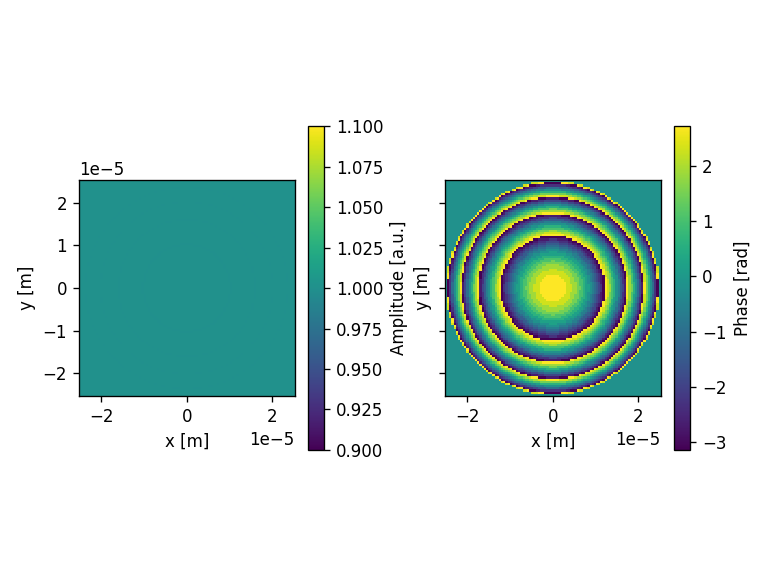

In [4]:
# Generate a uniform field
field = moe.field.create_empty_field_from_aperture(mask2)

field = moe.field.generate_uniform_field(field, E0=1)

# Modulates the field 
field = moe.field.modulate_field(field, amplitude_mask=None, phase_mask=mask2 )

# Plots the field (amplitude and phase)
moe.plotting.plot_field(field)

plt.tight_layout()
plt.show()


In [5]:
#Initial guess matrix

x_pixel, y_pixel = 100, 100


x0 = np.random.rand(x_pixel, y_pixel) 
x0_flatten = x0.flatten()


xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi)
 

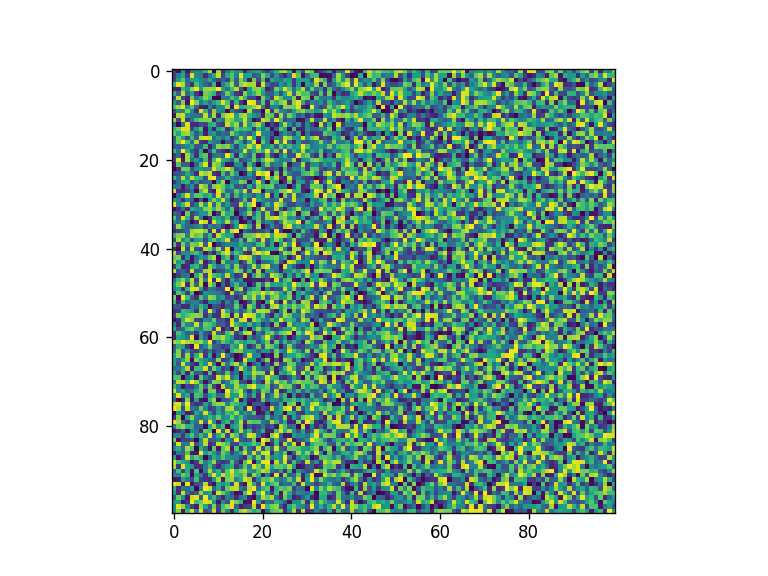

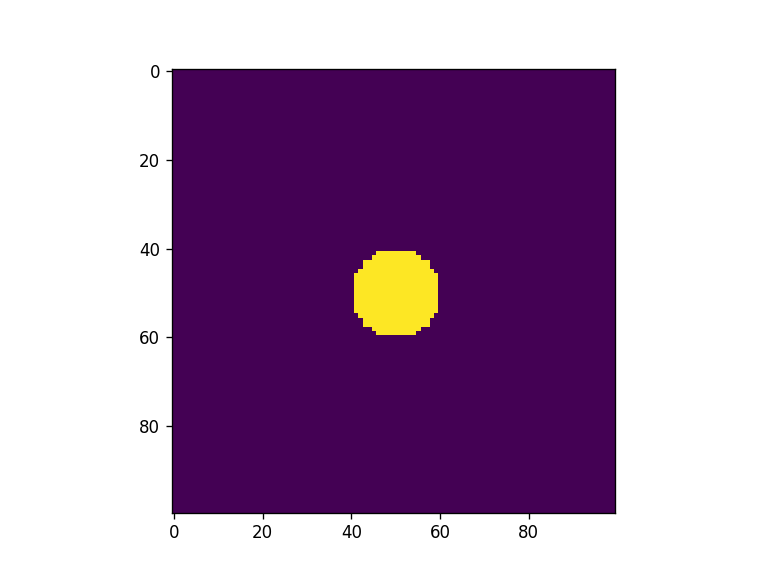

In [6]:
#create target matrix (central cricular pattern) 

matrix = np.zeros((x_pixel, y_pixel))
matrix[np.where(((XX-x_pixel/2)**2 + (YY-y_pixel/2)**2) < 10**2)] = 1 

matrix_flat = matrix.flatten()

fig = plt.figure() 
plt.imshow(x0)


fig = plt.figure() 
plt.imshow(matrix)

In [7]:
#Define Screen 

# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

focal_length = 0.02

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.array([focal_length])


screen = moe.field.Screen(x,y,z)

#### Brief propagation method comparison 
The optimization will make use of the field propagated compared towards a target. In this respect accurate propagation is key. To investigate this aspect and investigate Bluestein, ASM and SASM propagation reliability at large distances and its connection with padding, below we look at some propagation examples.

Elapsed: 0:00:01.057539


C:\Users\jcunha377\AppData\Roaming\Python\Python311\site-packages\jax\_src\numpy\lax_numpy.py:148: UserWarning: Explicitly requested dtype complex128 requested in asarray is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return asarray(x, dtype=self.dtype)


Elapsed: 0:00:12.561468
Elapsed: 0:00:01.780725


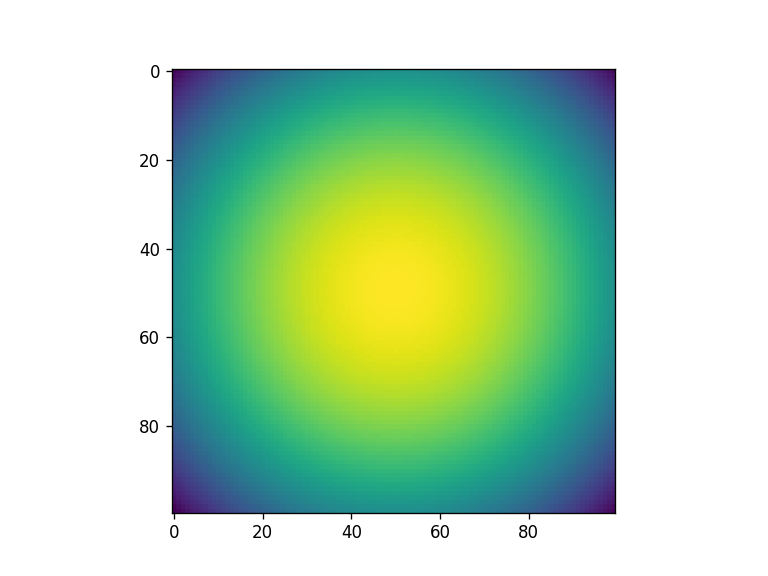

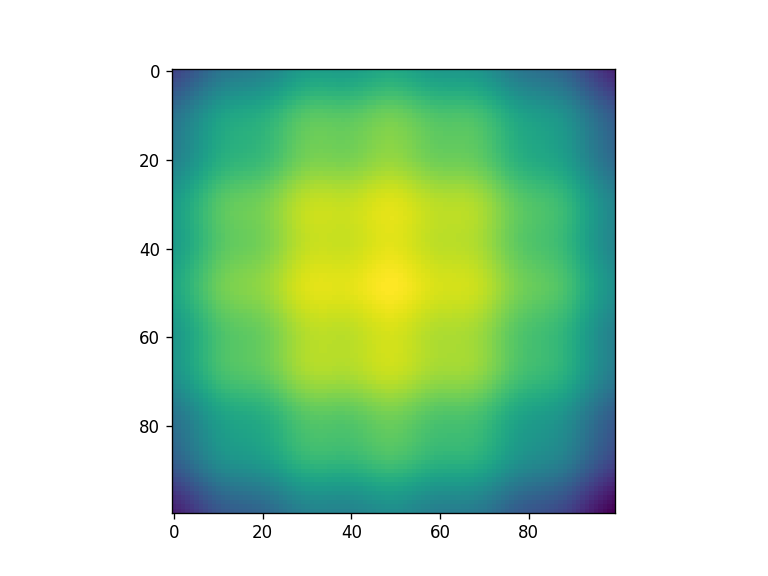

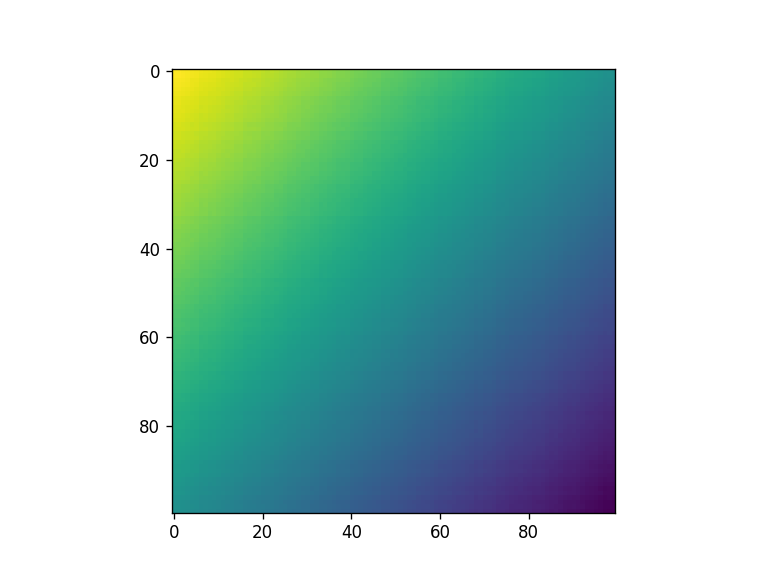

In [8]:
##check initial guess propagation with bluestein propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="bluestein"))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="ASM", pad_factor=2000))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="ASM", pad_factor=20))

fig = plt.figure() 
plt.imshow(np.abs(prop))

The ASM propagation does not provide a realible result already at f=0.15 mm, unless proper padding is employed. 

Elapsed: 0:00:00.016926
Elapsed: 0:00:22.811767


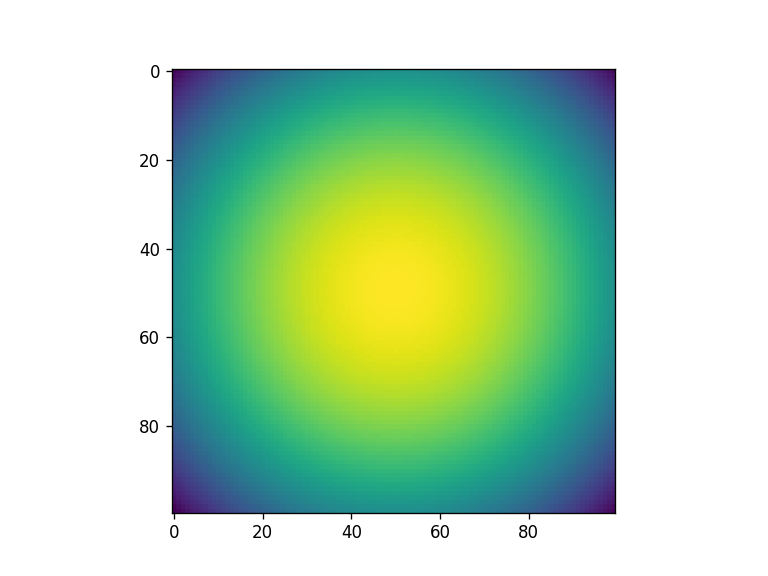

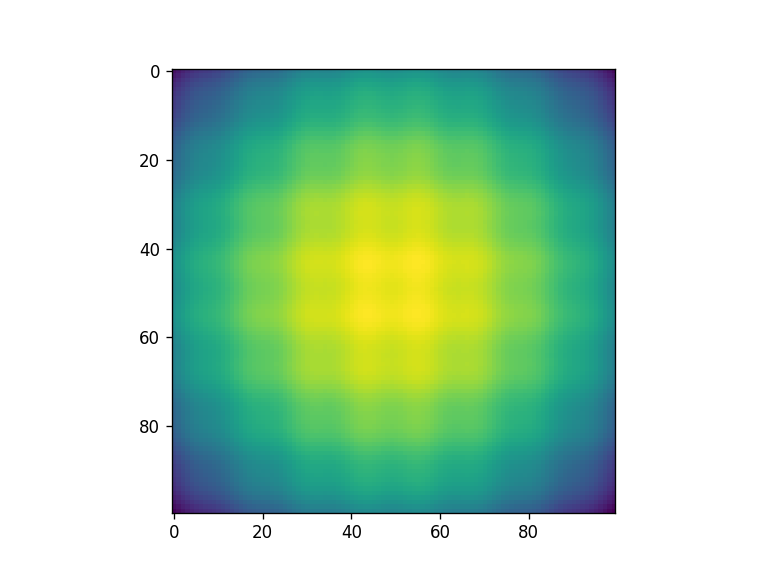

In [9]:
# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

focal_length = 0.02

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.array([focal_length])


screen = moe.field.Screen(x,y,z)


##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="bluestein"))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="ASM", pad_factor=3000))

fig = plt.figure() 
plt.imshow(np.abs(prop))

Elapsed: 0:00:00.020850
Elapsed: 0:00:38.485608


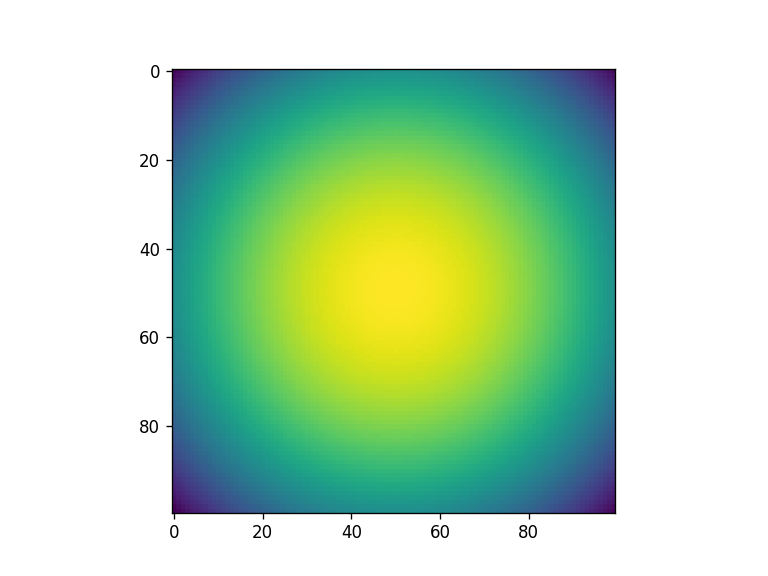

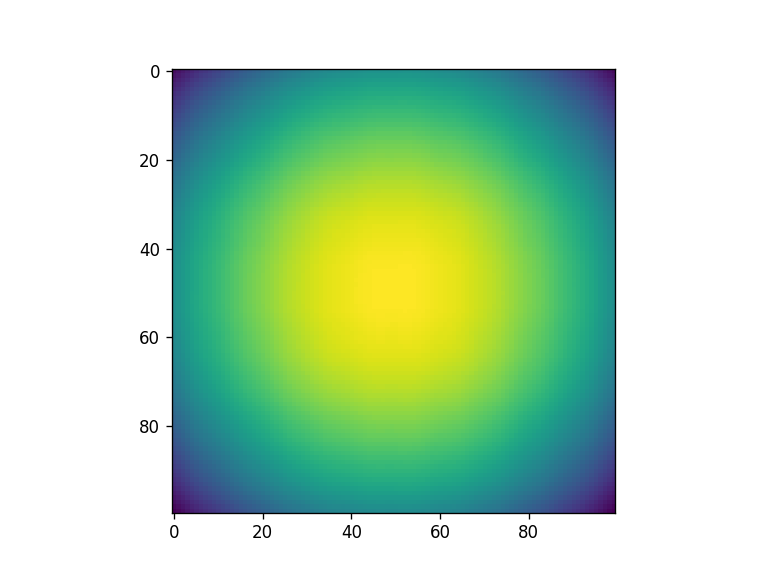

In [10]:
# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

focal_length = 0.02

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.array([focal_length])


screen = moe.field.Screen(x,y,z)


##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="bluestein"))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="ASM", pad_factor=4000))

fig = plt.figure() 
plt.imshow(np.abs(prop))


Elapsed: 0:00:00.017920
Elapsed: 0:00:39.867593
Elapsed: 0:00:00.032859


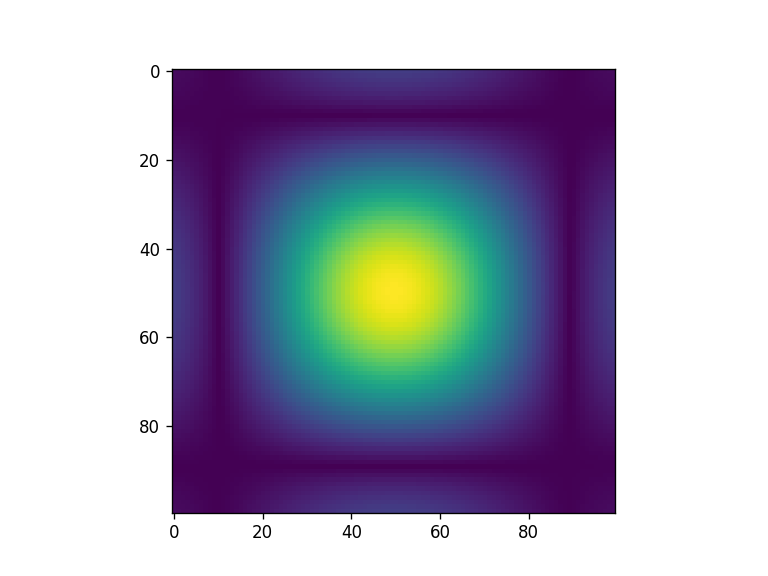

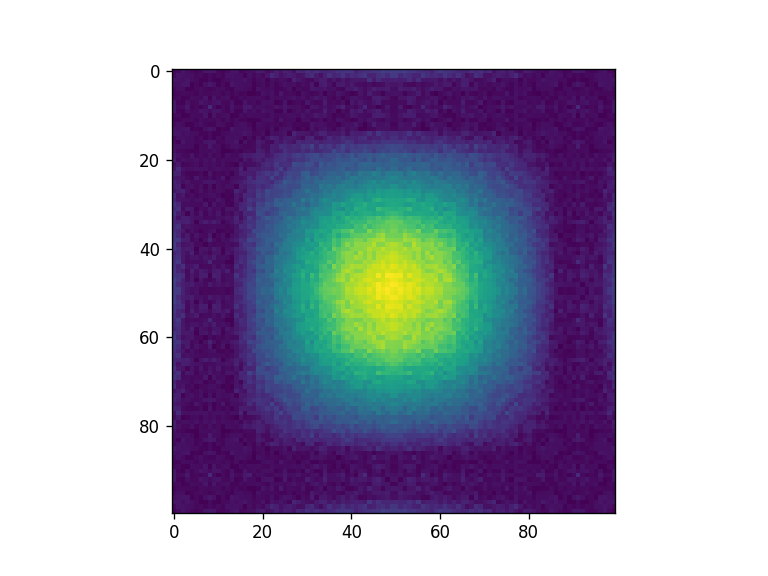

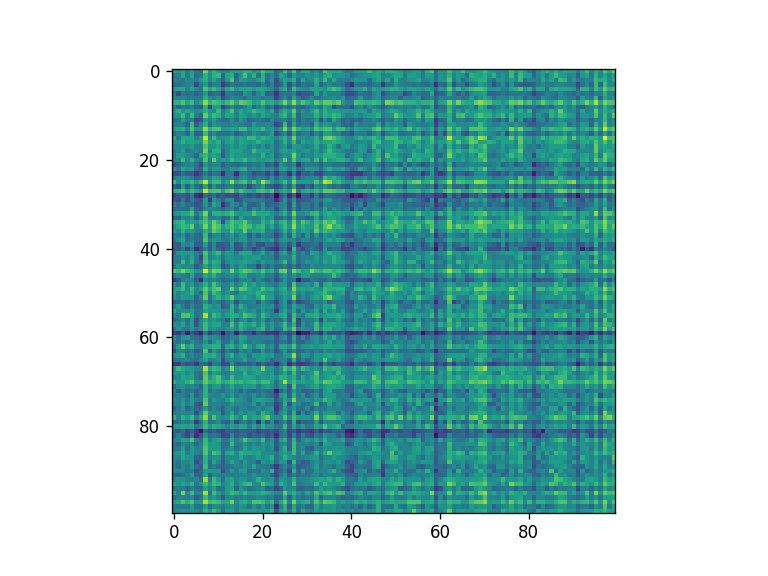

In [11]:
# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

focal_length = 0.2

x = np.linspace(xmin*100, xmax*100, x_pixel)
y = np.linspace(ymin*100, ymax*100, y_pixel)
z = np.array([focal_length])


screen = moe.field.Screen(x,y,z)


##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="bluestein"))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="ASM", pad_factor=4096))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="ASM", pad_factor=20))

fig = plt.figure() 
plt.imshow(np.abs(prop))

Above it is seen that even with large padding ASM gets blurry at larger distances.

And below we increase the distance and confirm both ASM and BLAS do not show a satisfactory result, unless we increase the padding - although still, it is not perfect. 

Elapsed: 0:00:00.025886
Elapsed: 0:00:14.114955
Elapsed: 0:00:49.871934


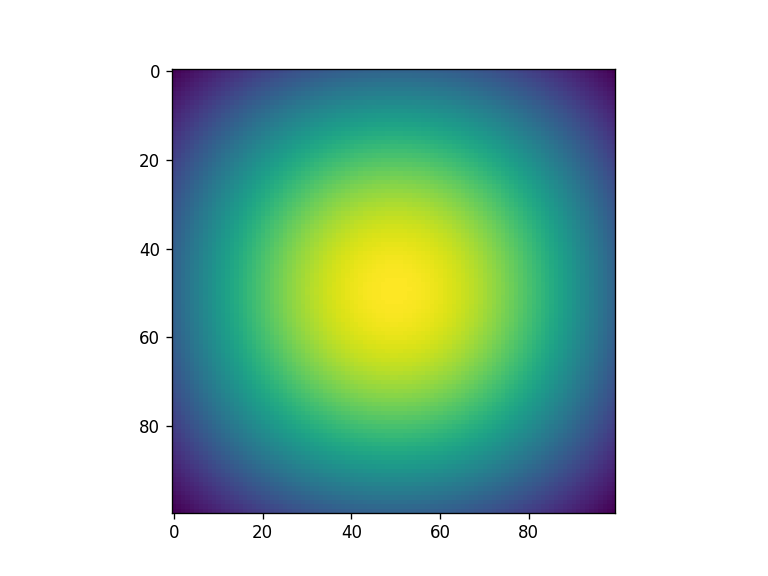

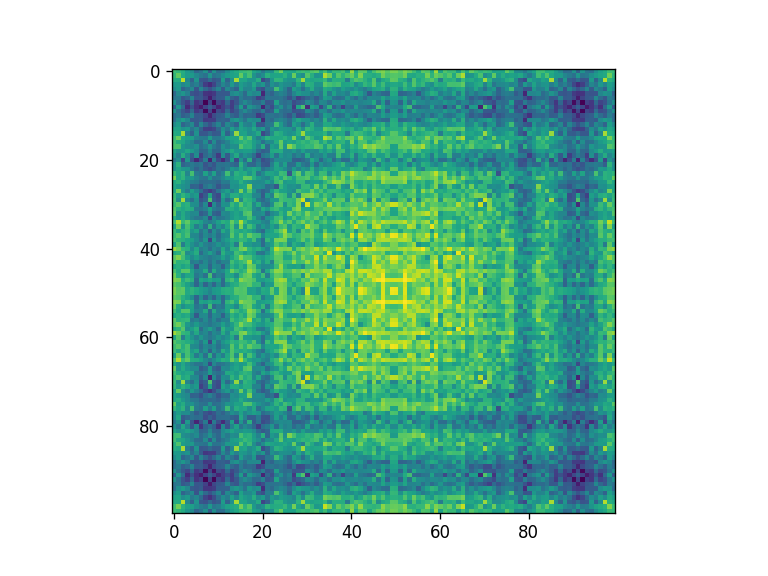

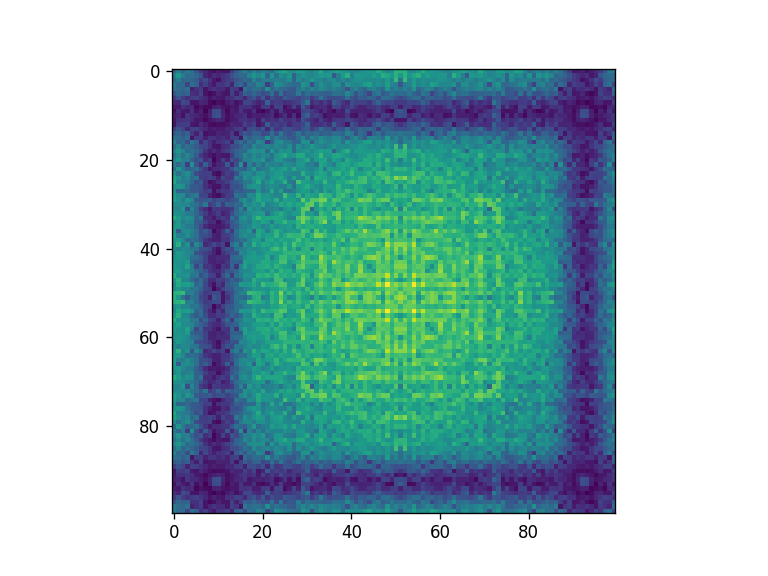

In [12]:
# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

focal_length = 0.4

x = np.linspace(xmin*100, xmax*100, x_pixel)
y = np.linspace(ymin*100, ymax*100, y_pixel)
z = np.array([focal_length])


screen = moe.field.Screen(x,y,z)


##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="bluestein"))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="ASM", pad_factor=4096))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="ASM", modedef = "BLAS", pad_factor=4096))

fig = plt.figure() 
plt.imshow(np.abs(prop))



Elapsed: 0:00:00.017921
Elapsed: 0:02:32.967984
Elapsed: 0:02:46.934386


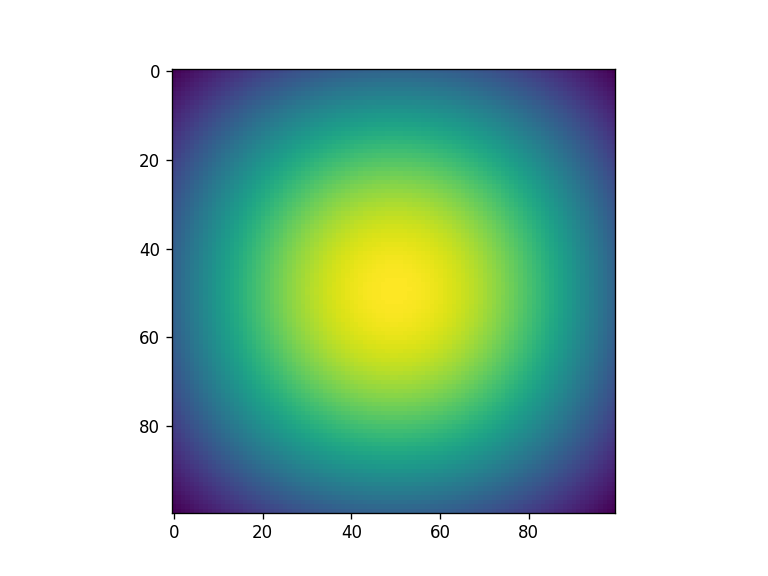

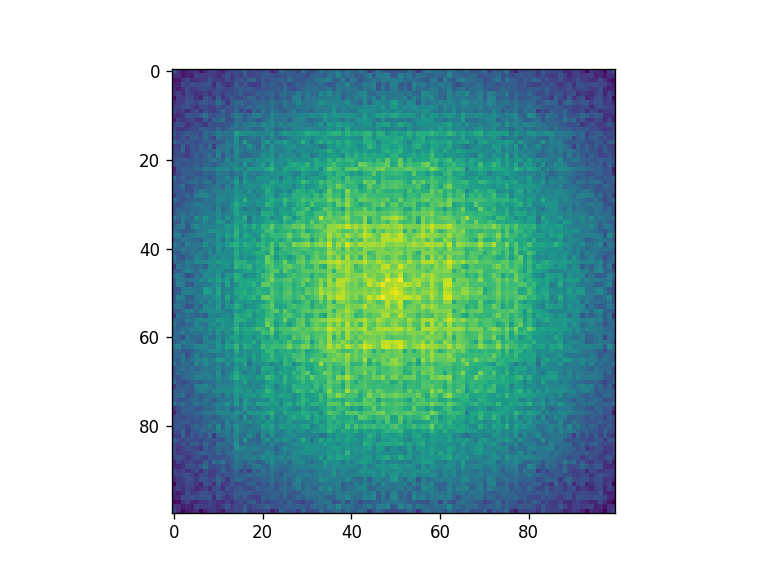

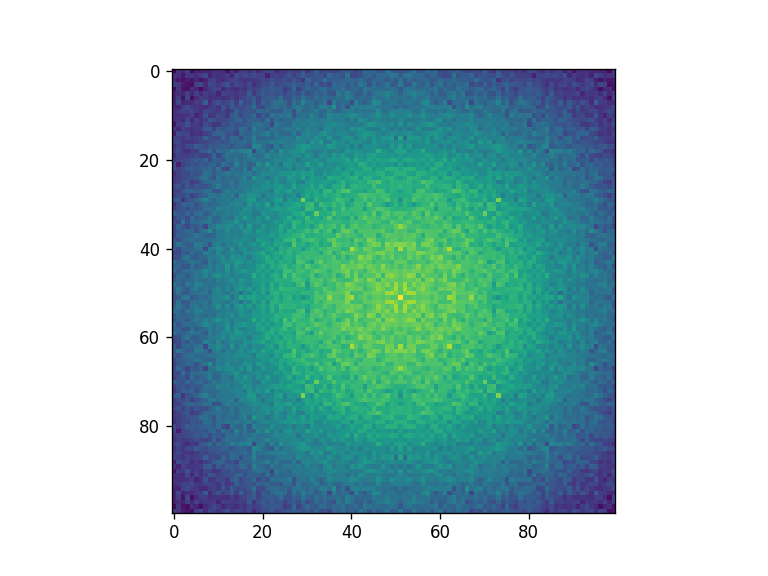

In [13]:
# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

focal_length = 0.4

x = np.linspace(xmin*100, xmax*100, x_pixel)
y = np.linspace(ymin*100, ymax*100, y_pixel)
z = np.array([focal_length])


screen = moe.field.Screen(x,y,z)


##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="bluestein"))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="ASM", modedef = "czt", pad_factor=2*4096))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="ASM", modedef = "BLAS", pad_factor=2*4096))

fig = plt.figure() 
plt.imshow(np.abs(prop))

SASM, while it seems to improve over the ASM (with czt or BLAS), seems to not be perfect as well. 

Elapsed: 0:00:00.028389
Zlimit is 0.018172018 but z is 0.4
Zlimit is 0.018172018 but z is 0.4
Elapsed: 0:00:00.066707


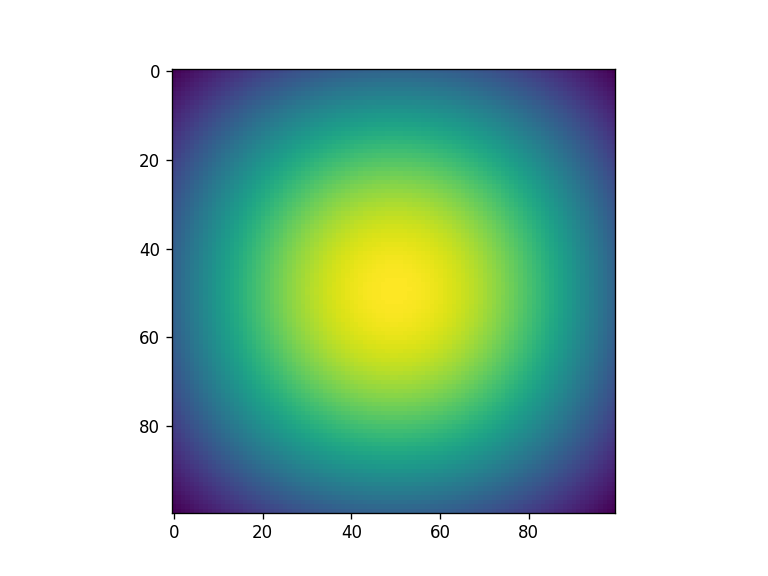

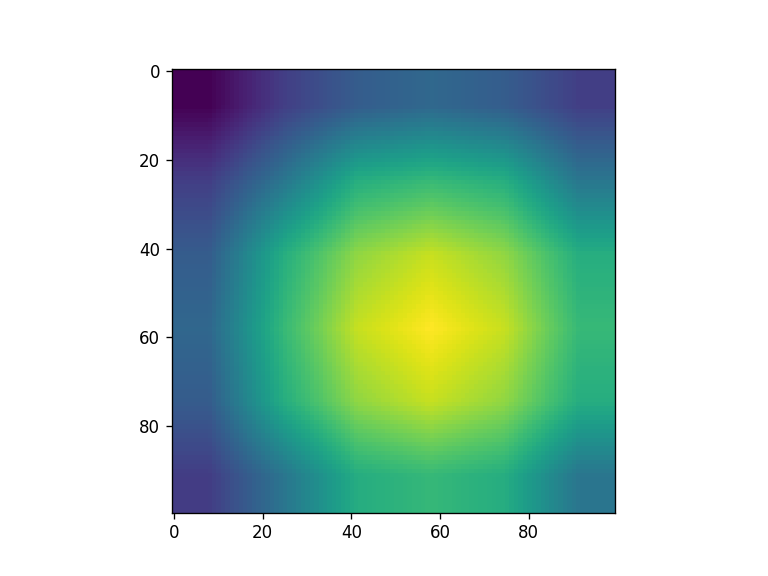

In [14]:
# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

focal_length = 0.4

x = np.linspace(xmin*100, xmax*100, x_pixel)
y = np.linspace(ymin*100, ymax*100, y_pixel)
z = np.array([focal_length])


screen = moe.field.Screen(x,y,z)


##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="bluestein"))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="SASM", pad_factor=5))

fig = plt.figure() 
plt.imshow(np.abs(prop))


In any case ASM based methods are more robust at shorter distances and less prone to padding. 

Elapsed: 0:00:00.017920
Elapsed: 0:00:01.751330
Elapsed: 0:00:00.034387


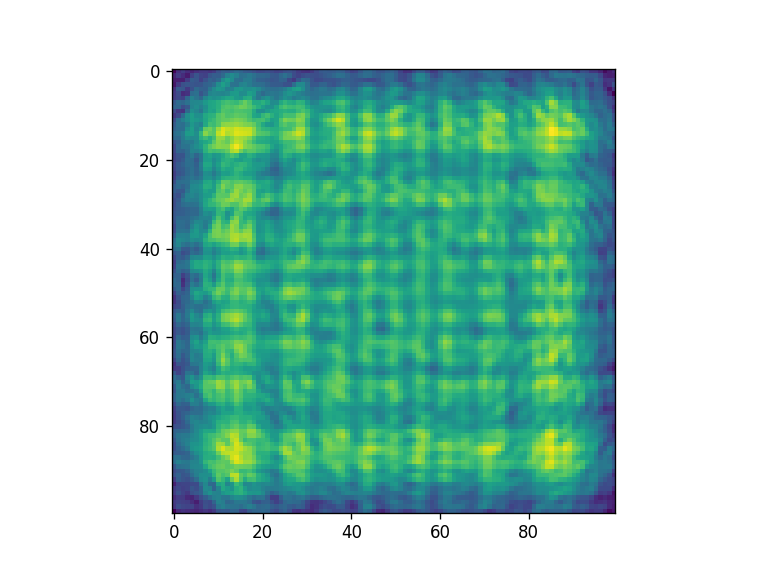

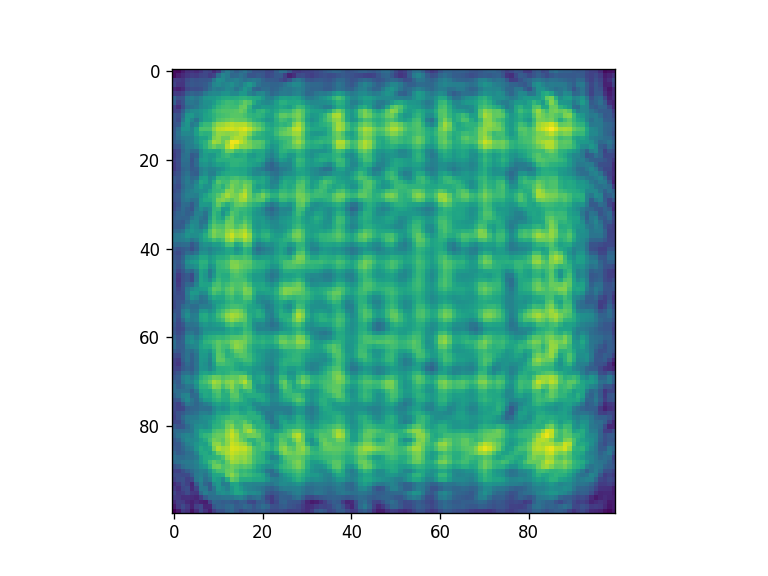

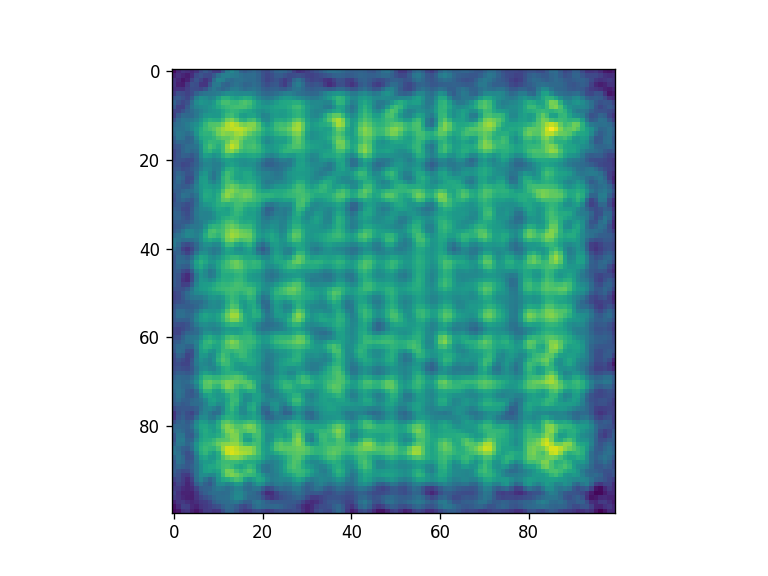

In [15]:
# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

focal_length = 0.00015

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.array([focal_length])


screen = moe.field.Screen(x,y,z)


##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="bluestein"))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="ASM", pad_factor=200))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="ASM", pad_factor=20))

fig = plt.figure() 
plt.imshow(np.abs(prop))

#### Optimization framework

The optimization framework passes through the definition of loss functions (FOM). Here simply they compare the propagation against a defined target. The loss function takes the propagation method as parameter, so it that different parameters can be tested. 

In [16]:
#Define loss functions 

def FOM(x, mask, screen, wavelength, mat=matrix_flat, propag="bluestein"):
    import jax.numpy as np 
    
    prop_x = np.abs(moe.optimizer.propagate(np.reshape(x, (x_pixel, y_pixel)), mask, screen, wavelength, propagation_method=propag).flatten())
    res = np.log(np.sum(((prop_x/np.max(prop_x)-mat/np.max(mat))**2)))
    #print(res)
    return re


def FOM2(x, mask, screen, wavelength, mat=matrix_flat, propag="bluestein"): 
    import jax.numpy as np 
    
    prop_x = np.abs(moe.optimizer.propagate(np.reshape(x, (x_pixel, y_pixel)), mask, screen, wavelength, propagation_method=propag).flatten())
    prop_x = np.reshape(prop_x, (x_pixel, y_pixel))
    midx, midy = int(x_pixel/2), int(y_pixel/2)
    mat = np.reshape(mat, (x_pixel, y_pixel))
    
    res = np.log(np.sum(((prop_x/np.max(prop_x)/(prop_x[(midx,midy)]/np.max(prop_x)) - mat/np.max(mat))**2)))
    
    #print(res, prop_x[(midx,midy)])#(prop_x[midx]/np.max(prop_x)-mat[midy]/np.max(mat))**2)
    return res


def FOM3(x, mask, screen, wavelength, mat, propag="bluestein"): 
    import jax.numpy as np 
    
    prop_x =  np.abs(moe.optimizer.propagate(np.reshape(x, (len(screen.x), len(screen.y))), mask, screen, wavelength, propagation_method=propag))
    
    diff = np.abs(prop_x/np.max(prop_x) - mat/np.max(mat))**2
     
    #print(diff.shape)
    res = np.sum(diff)
    #print(res)
    
    return res



In [17]:
# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

# Populate Aperture with Fresnel mask 
mask2 = moe.generate.fresnel_phase(aperture1, focal_length, wavelength )

#moe.plotting.plot_aperture(mask2)

#fig = plt.figure() 
#plt.imshow(np.abs(np.array(propagate(mask2.aperture, mask2, screen, wavelength) ) ))

In [18]:
# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

# the distance (called focal_length by chance, we are not focusing here) 
# is maintained in a range that is close enough so that ASM and SASM can be used without much troubles 
focal_length = 0.00015

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.array([focal_length])


screen = moe.field.Screen(x,y,z)

Below we demonstrate several optimizations using Bluestein, ASM and SASM propagators. All of them yield acceptable inverse designed masks. 

Elapsed: 0:00:00.019861
Elapsed: 0:00:00.286050
Elapsed: 0:00:00.015930
Elapsed: 0:00:00.040846
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.039364
Elapsed: 0:00:00.019912
Elapsed: 0:00:00.041351
Elapsed: 0:00:00.014934
Elapsed: 0:00:00.053304
Elapsed: 0:00:00.014478
Elapsed: 0:00:00.038830
Elapsed: 0:00:00.014475
Elapsed: 0:00:00.014933
Elapsed: 0:00:00.037834
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.037834
Elapsed: 0:00:00.013938
Elapsed: 0:00:00.038830
Elapsed: 0:00:00.019913
Elapsed: 0:00:00.043808
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.038368
Elapsed: 0:00:00.014448
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.039362
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.040361
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.044338
Elapsed: 0:00:00.014956
Elapsed: 0:00:00.038342
Elapsed: 0:00:00.018449
Elapsed: 0:00:00.040821
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.038851
Elapsed: 0:00:00.018919
Elapsed: 0:00:00.016927
Elapsed: 0:00:00.038829
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.040820
Elapsed: 0:00:00

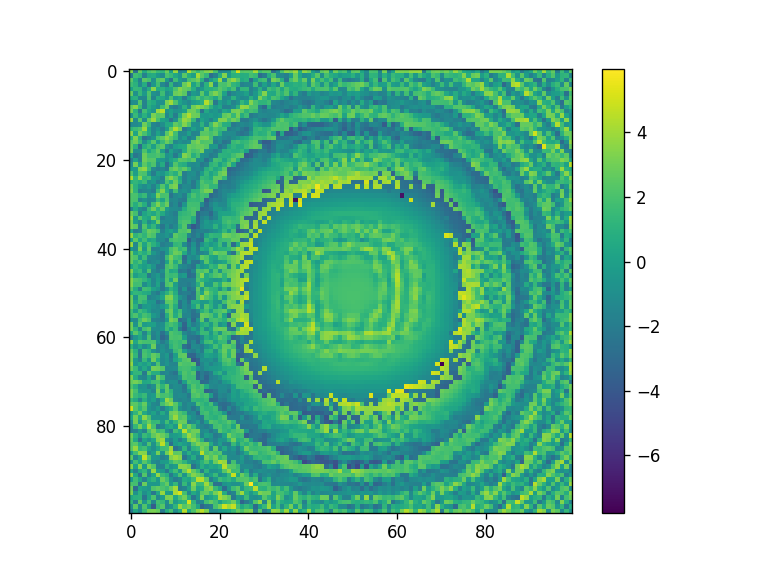

In [19]:
#optimize using the optimizer module  and Bluestein propagation (default) 
# the initial guess is the randimly initialized matrix 

solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=[mask2, screen, wavelength, matrix], verbose = 1, ftol=1e-4)

x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()


Elapsed: 0:00:00.014935
Elapsed: 0:00:00.021902


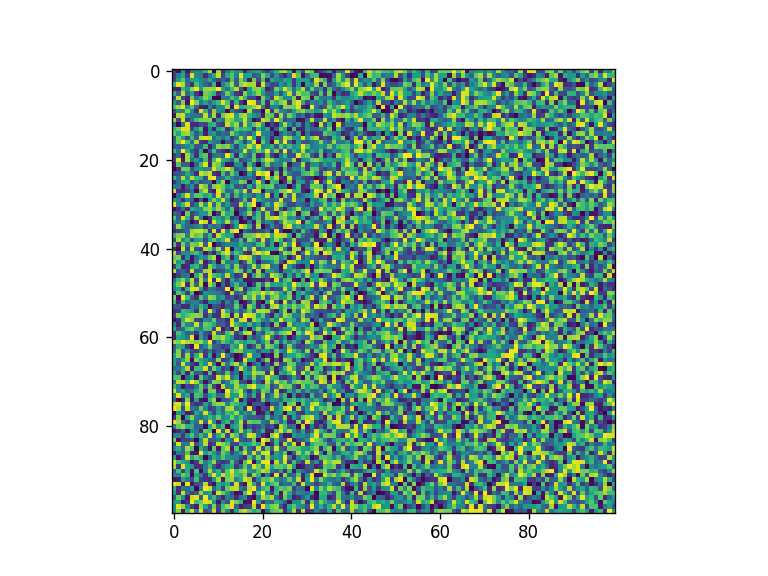

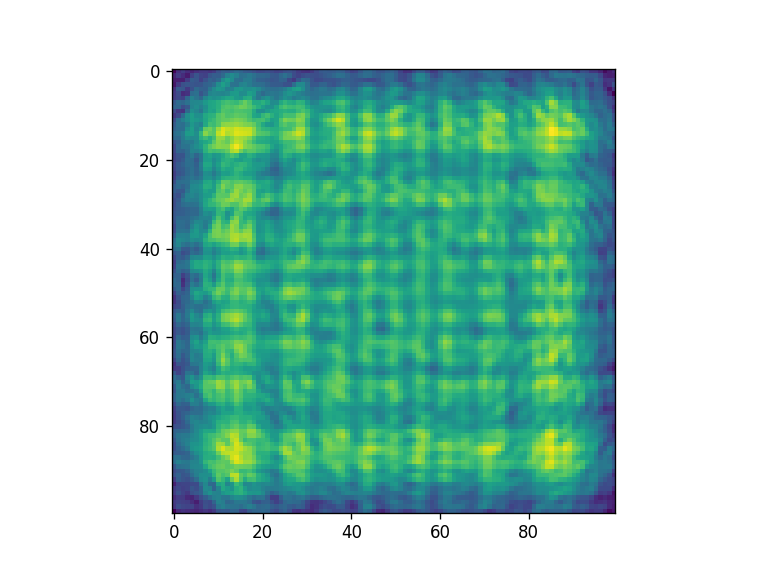

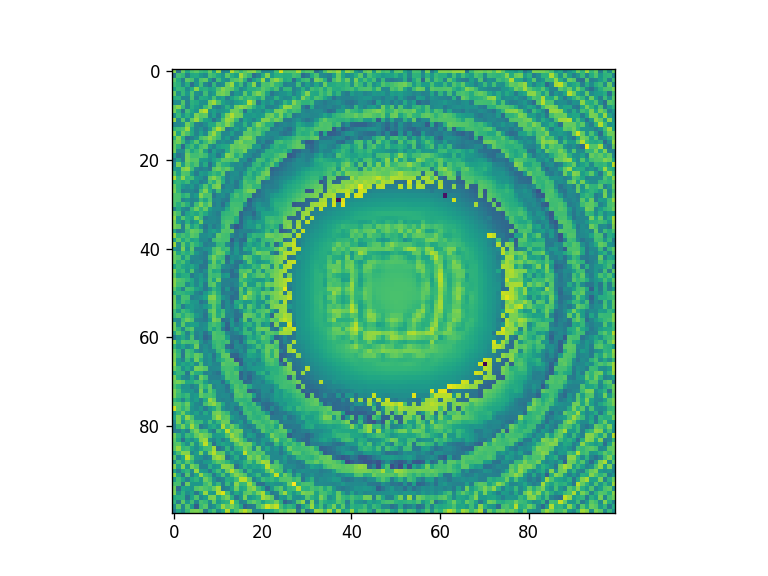

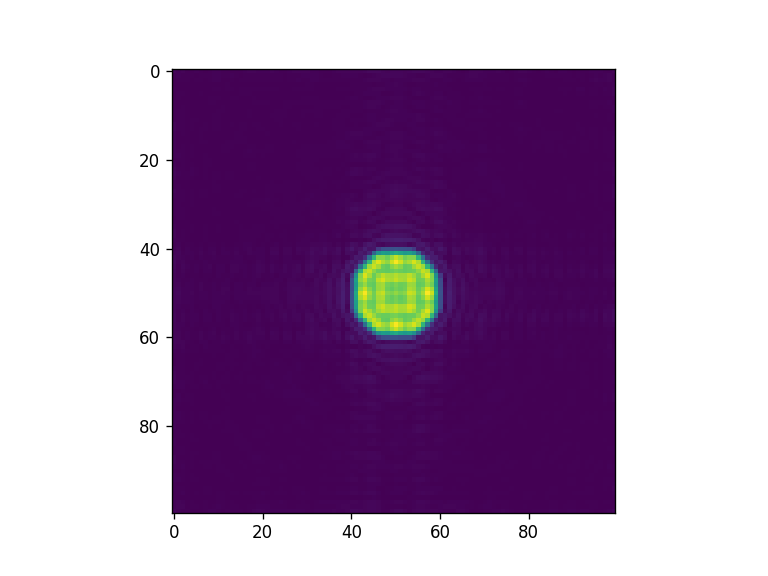

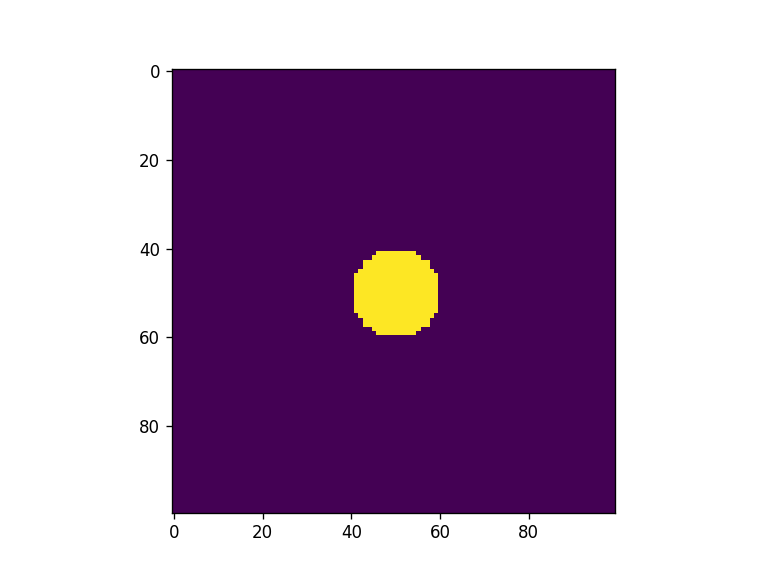

In [20]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) ) )

fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength) ) )


fig = plt.figure() 
plt.imshow(np.reshape(matrix, (x_pixel, y_pixel)) )


In [21]:
def FOM2(x, mask, screen, wavelength, mat, propag="bluestein"): 
    import jax.numpy as np 
    
    prop_x =  np.abs(moe.optimizer.propagate(np.reshape(x, (len(screen.x), len(screen.y))), mask, screen, wavelength, propagation_method=propag ))
    
    diff = np.abs(prop_x/prop_x[int(len(screen.x)/2), int(len(screen.y)/2)] - mat/np.max(mat))**2
     
    #print(diff.shape)
    res = np.log(np.sum(diff))
    #print(res)
    
    return res

In [22]:
## Optimization with ASM 

solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=[mask2, screen, wavelength, matrix, "ASM"], verbose = 1, ftol=1e-6)

Elapsed: 0:00:01.636084
Elapsed: 0:00:00.790216
Elapsed: 0:00:00.034845
Elapsed: 0:00:00.080646
Elapsed: 0:00:00.030864
Elapsed: 0:00:00.084628
Elapsed: 0:00:00.028873
Elapsed: 0:00:00.027877
Elapsed: 0:00:00.026882
Elapsed: 0:00:00.086621
Elapsed: 0:00:00.032855
Elapsed: 0:00:00.068699
Elapsed: 0:00:00.028874
Elapsed: 0:00:00.028873
Elapsed: 0:00:00.068718
Elapsed: 0:00:00.027877
Elapsed: 0:00:00.081642
Elapsed: 0:00:00.030865
Elapsed: 0:00:00.074672
Elapsed: 0:00:00.028872
Elapsed: 0:00:00.028873
Elapsed: 0:00:00.068698
Elapsed: 0:00:00.033851
Elapsed: 0:00:00.074672
Elapsed: 0:00:00.026882
Elapsed: 0:00:00.068699
Elapsed: 0:00:00.027876
Elapsed: 0:00:00.068698
Elapsed: 0:00:00.030865
Elapsed: 0:00:00.073678
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.075668
Elapsed: 0:00:00.035843
Elapsed: 0:00:00.082637
Elapsed: 0:00:00.027842
Elapsed: 0:00:00.072214
Elapsed: 0:00:00.027879
Elapsed: 0:00:00.069694
Elapsed: 0:00:00.043806
Elapsed: 0:00:00.073677
Elapsed: 0:00:00.029869
Elapsed: 0:00:00

Elapsed: 0:00:00.034846
Elapsed: 0:00:00.027878


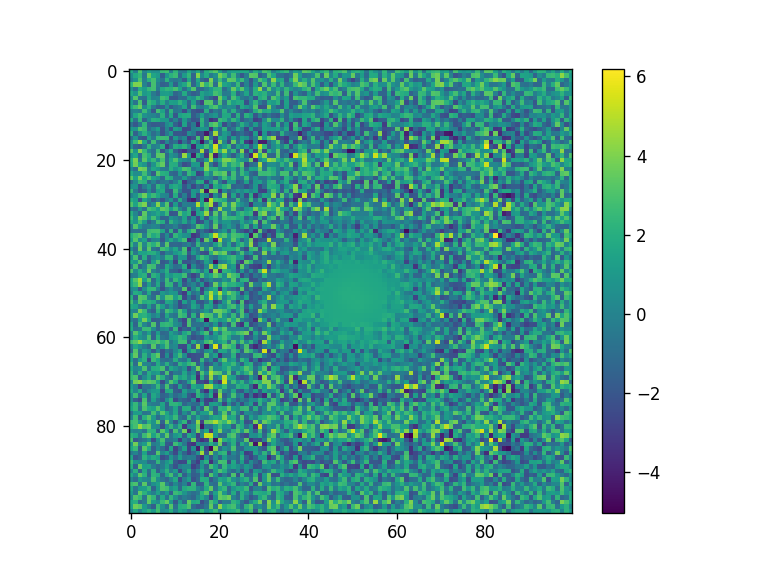

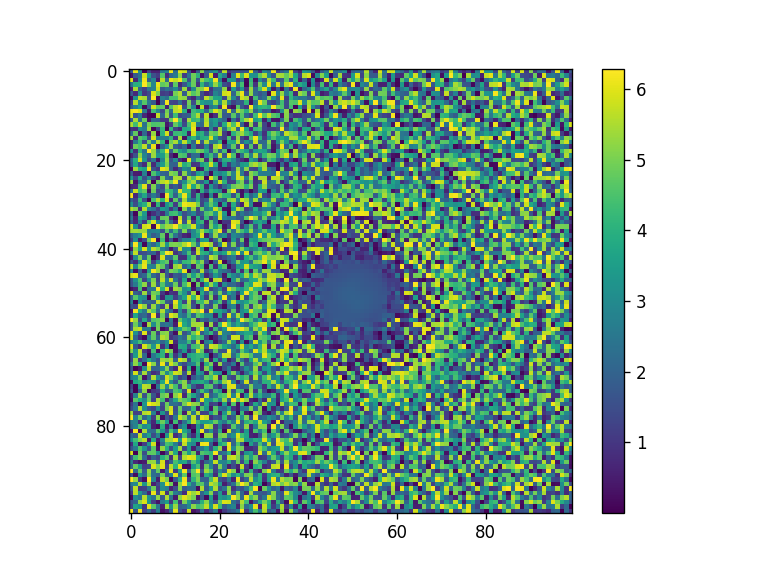

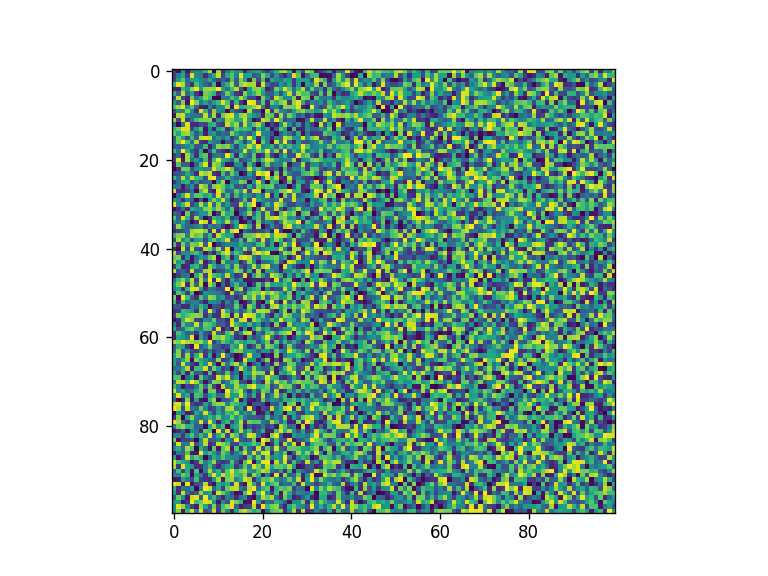

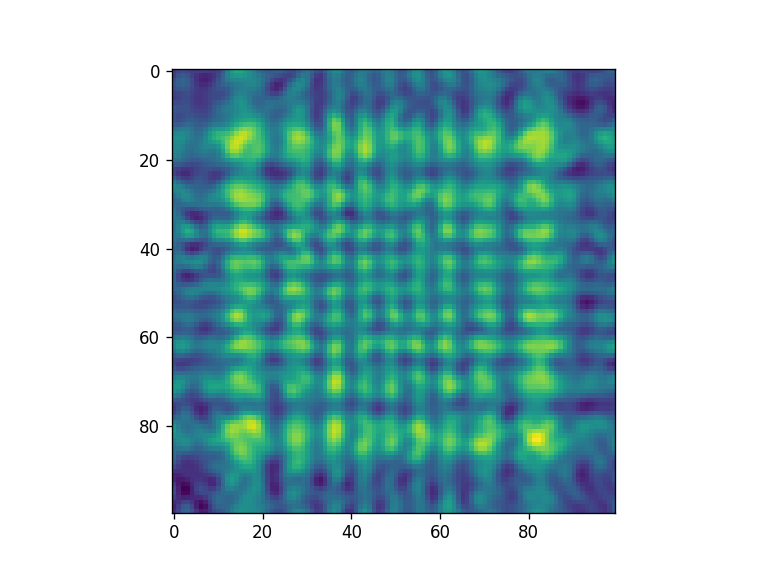

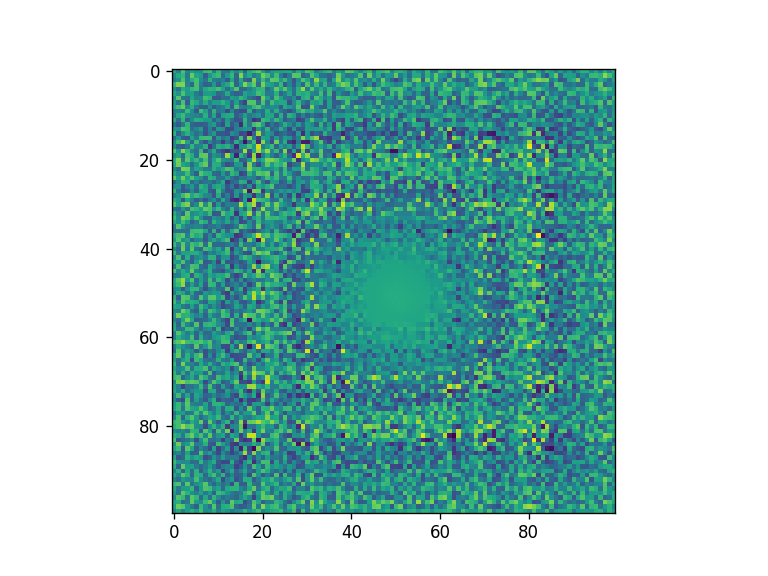

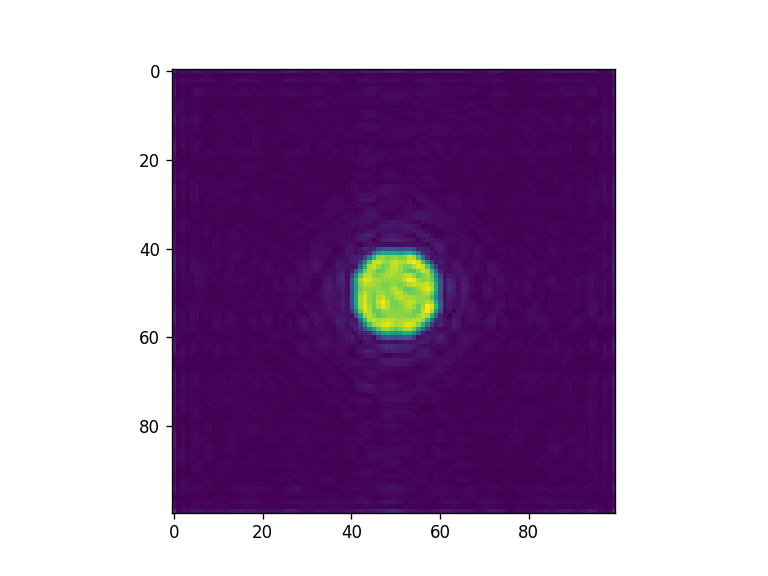

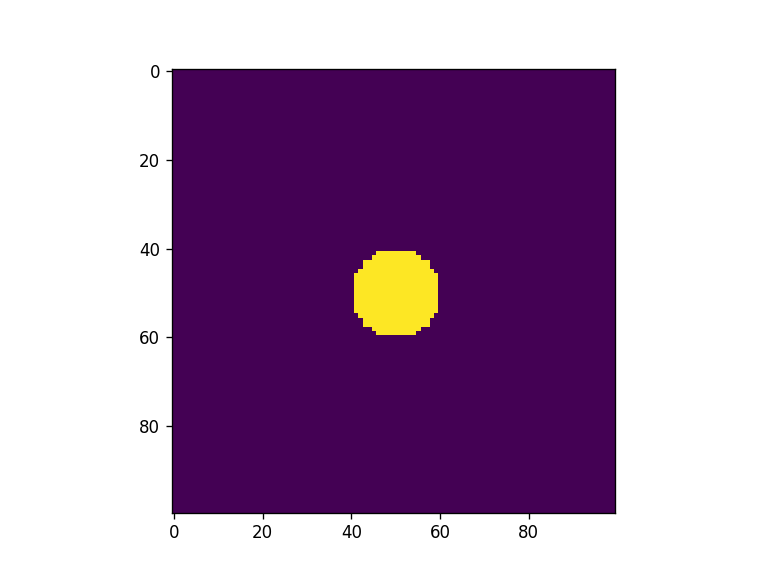

In [23]:
x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar%(2*np.pi)) 
plt.colorbar()

fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength, propagation_method="ASM") ) )

fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength, propagation_method="ASM") ) )


fig = plt.figure() 
plt.imshow(np.reshape(matrix, (x_pixel, y_pixel)) )


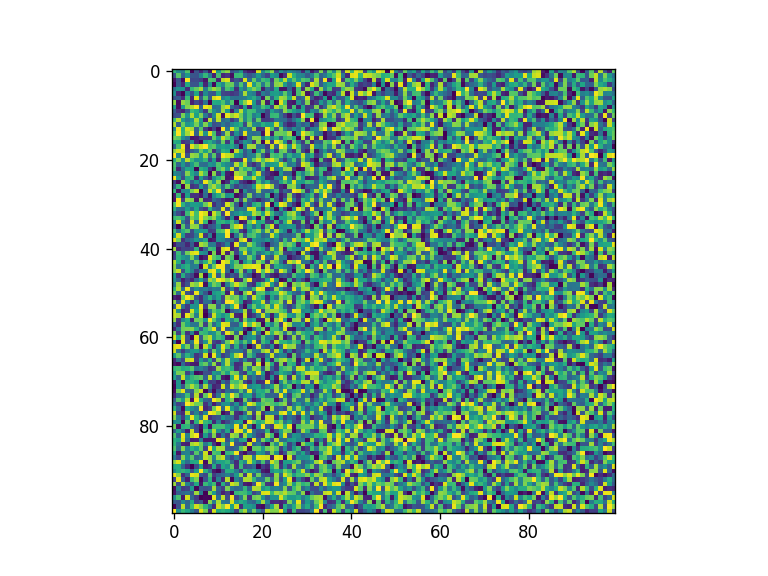

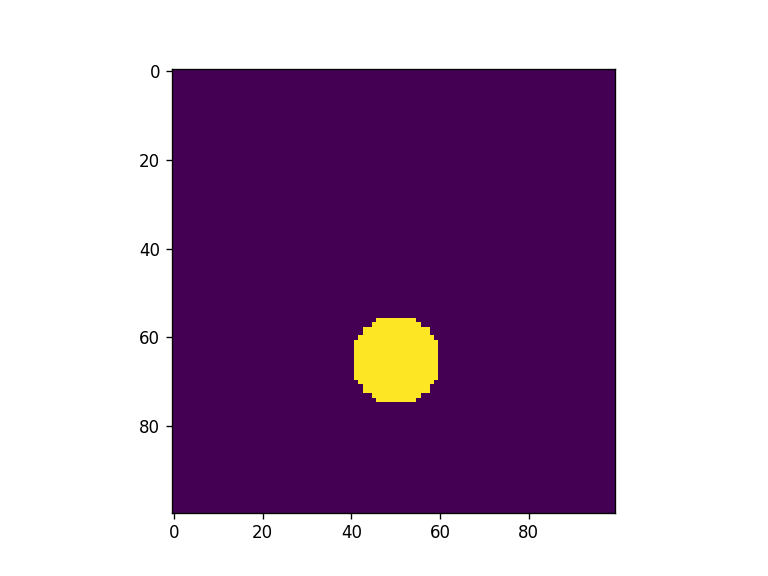

In [24]:
# re-define the Initial guess and target 
x_pixel, y_pixel = 100, 100

x0 = np.random.rand(x_pixel, y_pixel)
#x0 = np.ones((x_pixel, y_pixel))
x0_flatten = x0.flatten()

xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi)
    
matrix = np.zeros((x_pixel, y_pixel))
matrix[np.where(((XX-x_pixel/2- 0)**2 + (YY-y_pixel/2-15)**2) < 10**2)] = 1 

matrix_flat = matrix.flatten()

fig = plt.figure() 
plt.imshow(x0)


fig = plt.figure() 
plt.imshow(matrix)

Elapsed: 0:00:00.032802
Elapsed: 0:00:00.045799
Elapsed: 0:00:00.018943
Elapsed: 0:00:00.056752
Elapsed: 0:00:00.028894
Elapsed: 0:00:00.045799
Elapsed: 0:00:00.019912
Elapsed: 0:00:00.044803
Elapsed: 0:00:00.020908
Elapsed: 0:00:00.047792
Elapsed: 0:00:00.027876
Elapsed: 0:00:00.044832
Elapsed: 0:00:00.017921
Elapsed: 0:00:00.042812
Elapsed: 0:00:00.024890
Elapsed: 0:00:00.024889
Elapsed: 0:00:00.044803
Elapsed: 0:00:00.018917
Elapsed: 0:00:00.053762
Elapsed: 0:00:00.018917
Elapsed: 0:00:00.018433
Elapsed: 0:00:00.042811
Elapsed: 0:00:00.024889
Elapsed: 0:00:00.048786
Elapsed: 0:00:00.017921
Elapsed: 0:00:00.062724
Elapsed: 0:00:00.023895
Elapsed: 0:00:00.048784
Elapsed: 0:00:00.018918
Elapsed: 0:00:00.042813
Elapsed: 0:00:00.017922
Elapsed: 0:00:00.042812
Elapsed: 0:00:00.019910
Elapsed: 0:00:00.042813
Elapsed: 0:00:00.017922
Elapsed: 0:00:00.045334
Elapsed: 0:00:00.018917
Elapsed: 0:00:00.051772
Elapsed: 0:00:00.022413
Elapsed: 0:00:00.041816
Elapsed: 0:00:00.018917
Elapsed: 0:00:00

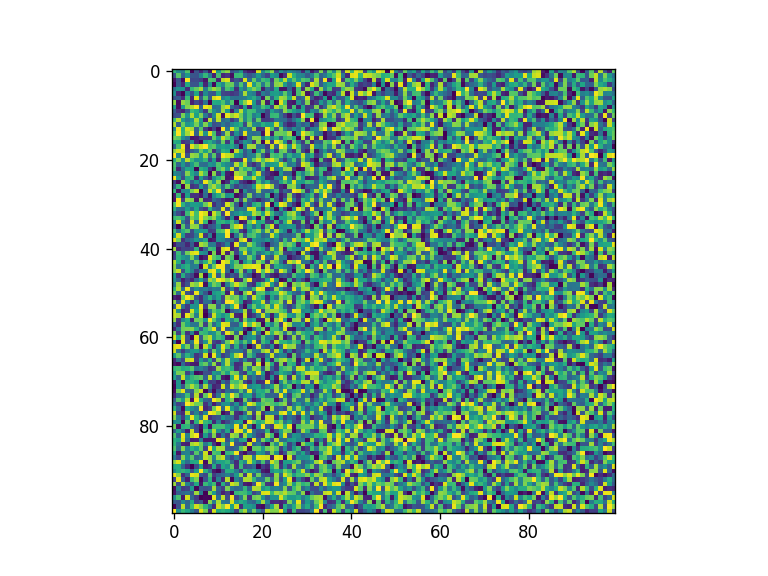

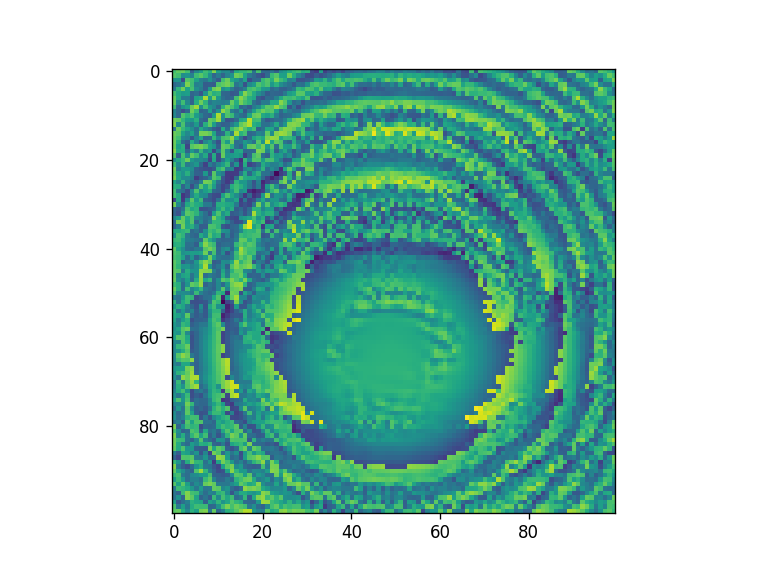

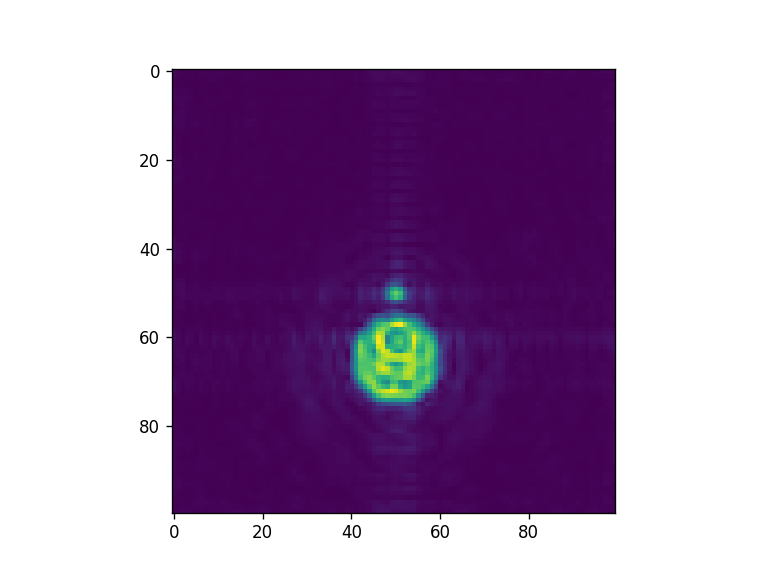

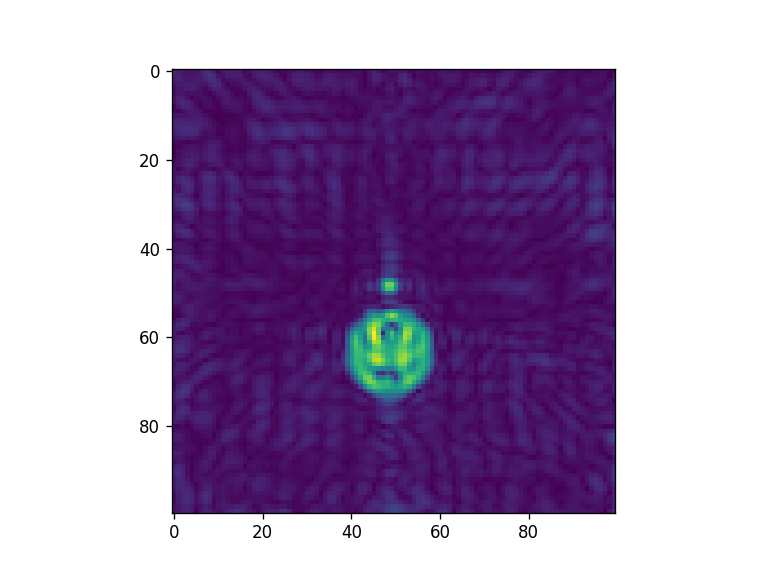

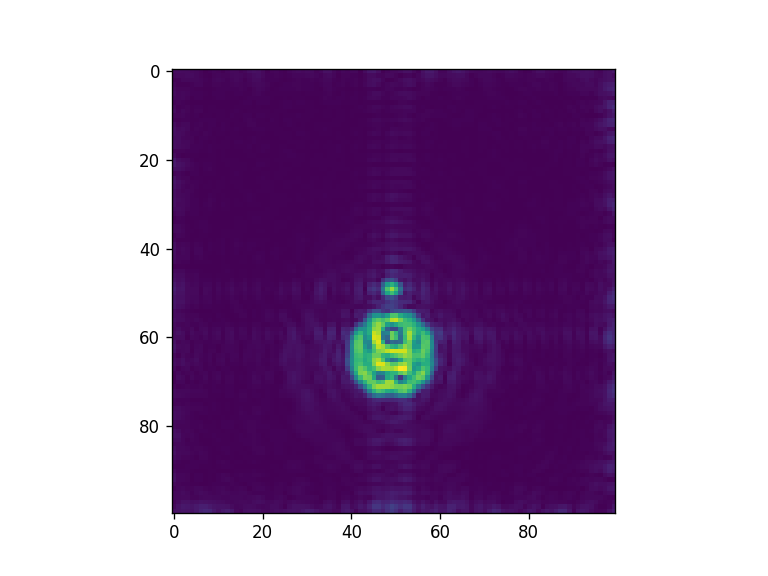

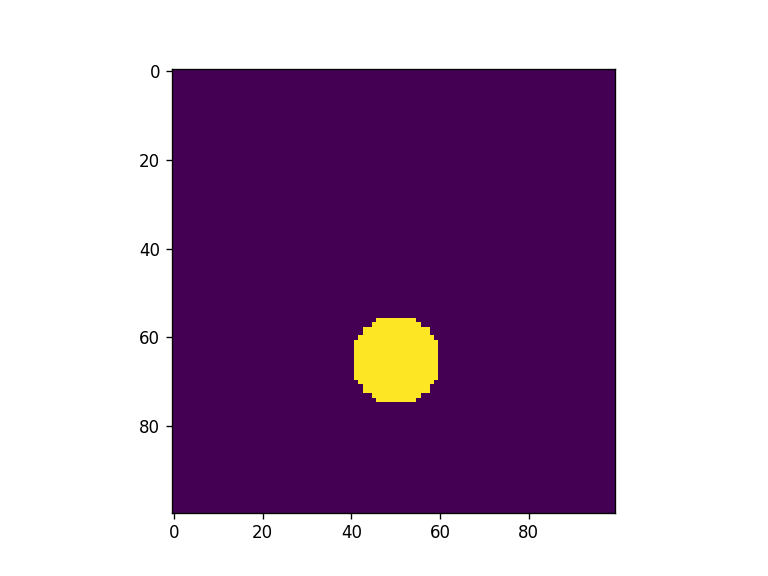

In [25]:
#Optimization with SASM 

solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=[mask2, screen, wavelength, matrix, "SASM"], verbose = 1, ftol=1e-3)

x = solution.x

fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength, propagation_method="SASM") ) )

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength, propagation_method="ASM") ) )
fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength) ) )


fig = plt.figure() 
plt.imshow(np.reshape(matrix, (x_pixel, y_pixel)) )


In [26]:
solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=[mask2, screen, wavelength, matrix, ], verbose = 1, ftol=1e-3)

x = solution.x

Elapsed: 0:00:00.016925
Elapsed: 0:00:00.040820
Elapsed: 0:00:00.016926
Elapsed: 0:00:00.040820
Elapsed: 0:00:00.015930
Elapsed: 0:00:00.041816
Elapsed: 0:00:00.014925
Elapsed: 0:00:00.038830
Elapsed: 0:00:00.013938
Elapsed: 0:00:00.038829
Elapsed: 0:00:00.014934
Elapsed: 0:00:00.038829
Elapsed: 0:00:00.013938
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.039824
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.039824
Elapsed: 0:00:00.014934
Elapsed: 0:00:00.015930
Elapsed: 0:00:00.040820
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.038829
Elapsed: 0:00:00.013938
Elapsed: 0:00:00.041840
Elapsed: 0:00:00.015930
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.038830
Elapsed: 0:00:00.013938
Elapsed: 0:00:00.038829
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.039825
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.038829
Elapsed: 0:00:00.019912
Elapsed: 0:00:00.050778
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.038830
Elapsed: 0:00:00.025025
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.038829
Elapsed: 0:00:00.017921
Elapsed: 0:00:00

Elapsed: 0:00:00.017922
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.019914


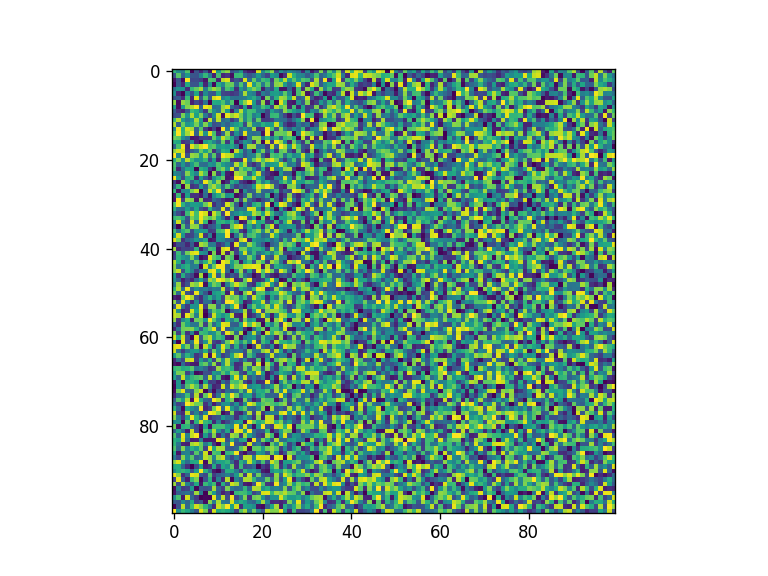

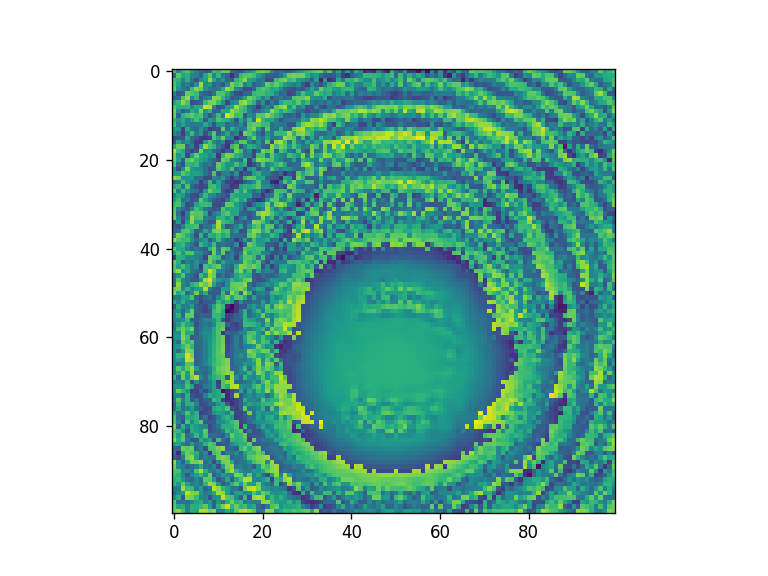

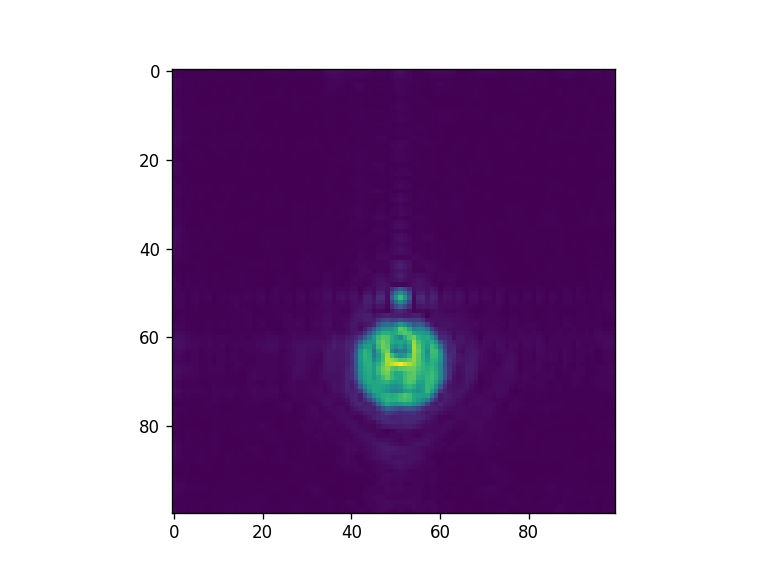

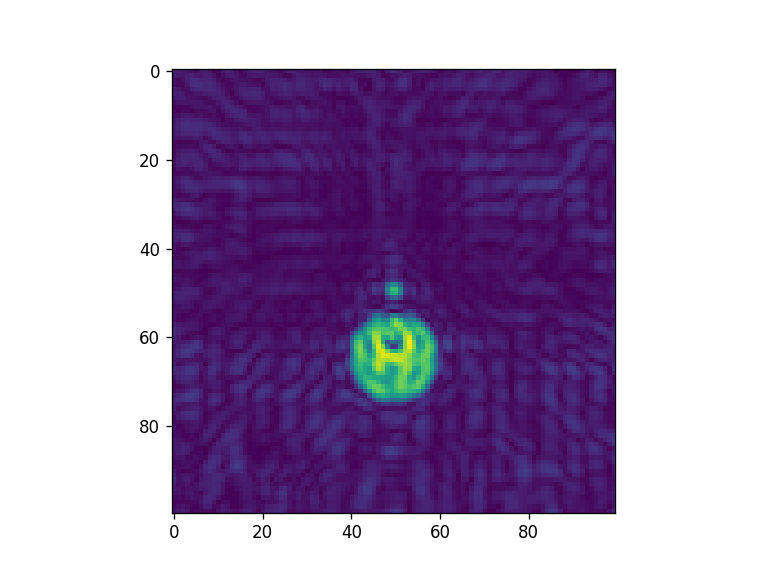

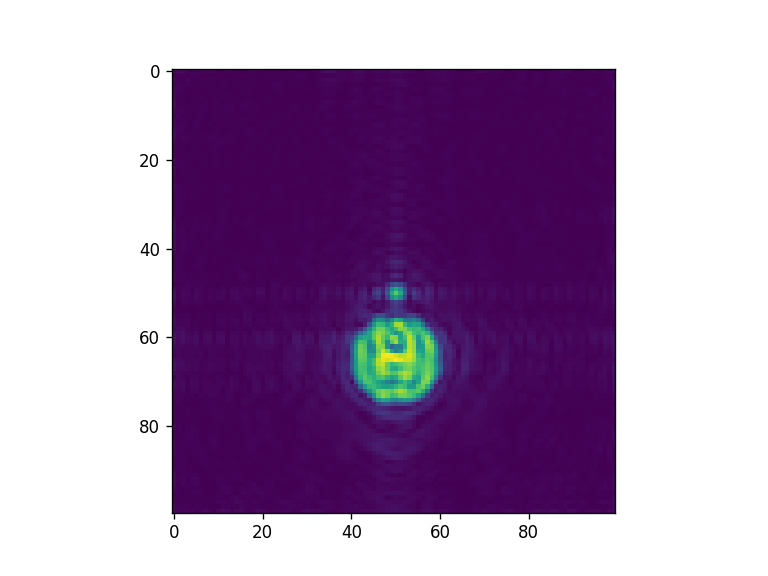

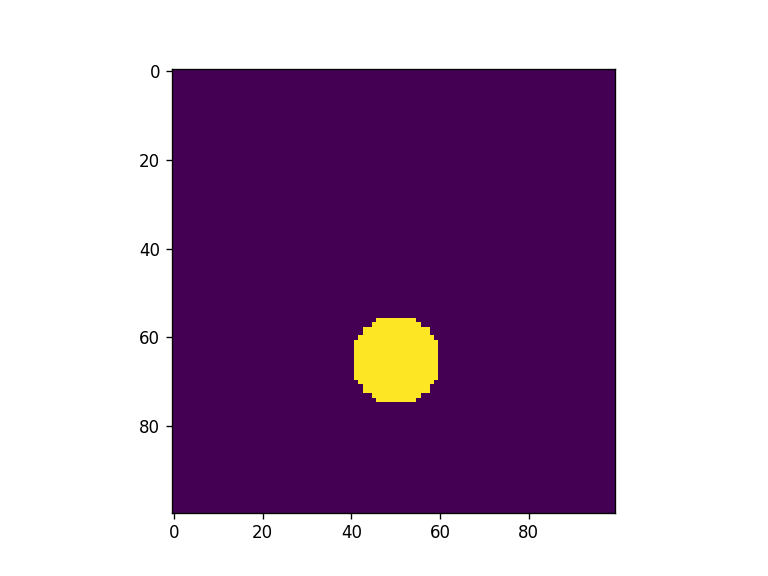

In [27]:

fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength, propagation_method="SASM") ) )

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength, propagation_method="ASM") ) )
fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength) ) )


fig = plt.figure() 
plt.imshow(np.reshape(matrix, (x_pixel, y_pixel)) )


Elapsed: 0:00:00.015931
Elapsed: 0:00:00.039825
Elapsed: 0:00:00.017954
Elapsed: 0:00:00.045799
Elapsed: 0:00:00.021904
Elapsed: 0:00:00.041817
Elapsed: 0:00:00.013938
Elapsed: 0:00:00.040820
Elapsed: 0:00:00.015932
Elapsed: 0:00:00.042812
Elapsed: 0:00:00.013938
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.041816
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.038830
Elapsed: 0:00:00.014934
Elapsed: 0:00:00.038829
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.039825
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.013940
Elapsed: 0:00:00.045799
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.043806
Elapsed: 0:00:00.014934
Elapsed: 0:00:00.038829
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.038829
Elapsed: 0:00:00.014936
Elapsed: 0:00:00.038829
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.039825
Elapsed: 0:00:00.015930
Elapsed: 0:00:00.013937
Elapsed: 0:00:00.039825
Elapsed: 0:00:00.014954
Elapsed: 0:00:00.039826
Elapsed: 0:00:00.016927
Elapsed: 0:00:00.038828
Elapsed: 0:00:00.013939
Elapsed: 0:00:00

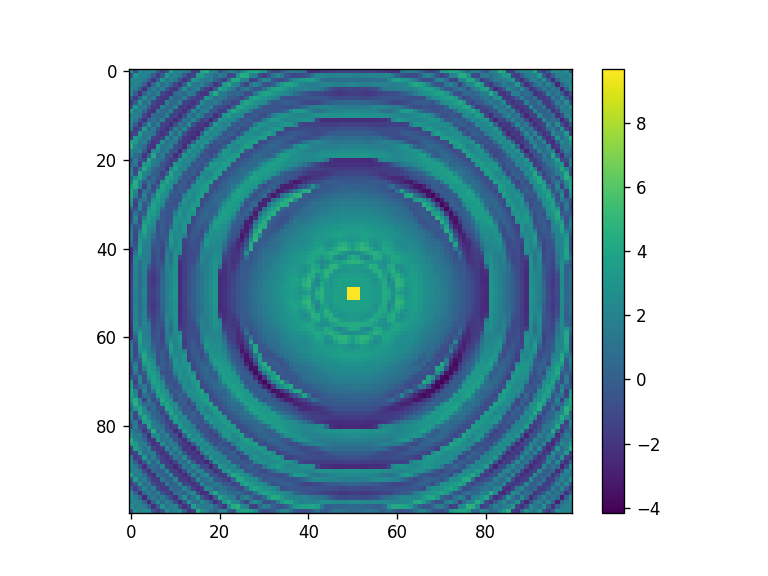

In [28]:
### Testing constant value initial guess 

#Initial guess
x_pixel, y_pixel = 100, 100


x0 = np.ones((x_pixel,y_pixel))
x0_flatten = x0.flatten()


xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi)
    
matrix = np.zeros((x_pixel, y_pixel))
matrix[np.where(((XX-x_pixel/2)**2 + (YY-y_pixel/2)**2) < 10**2)] = 1 

matrix_flat = matrix.flatten()


solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=[mask2, screen, wavelength, matrix, "bluestein"], verbose=1, ftol=1e-3)

x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

Elapsed: 0:00:00.015930
Elapsed: 0:00:00.015929


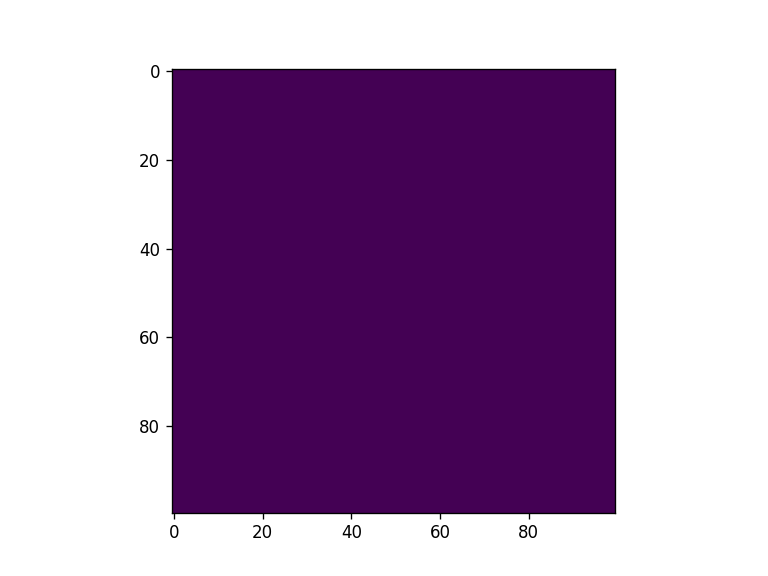

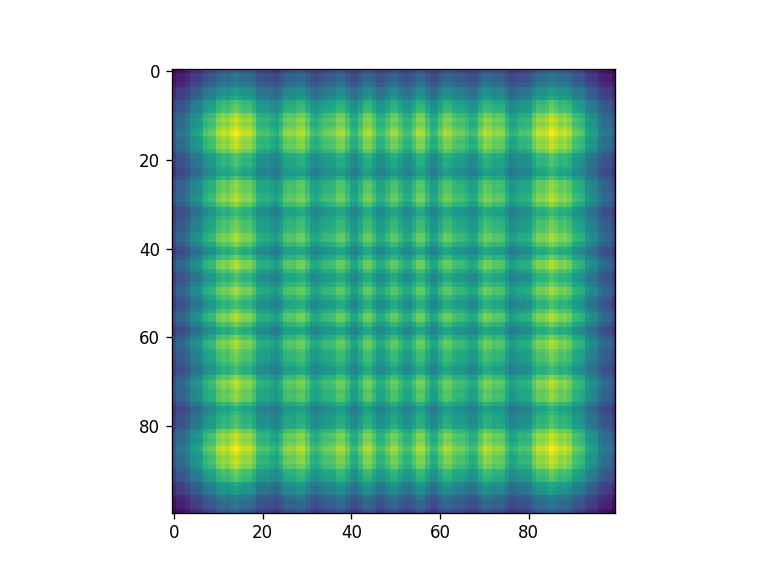

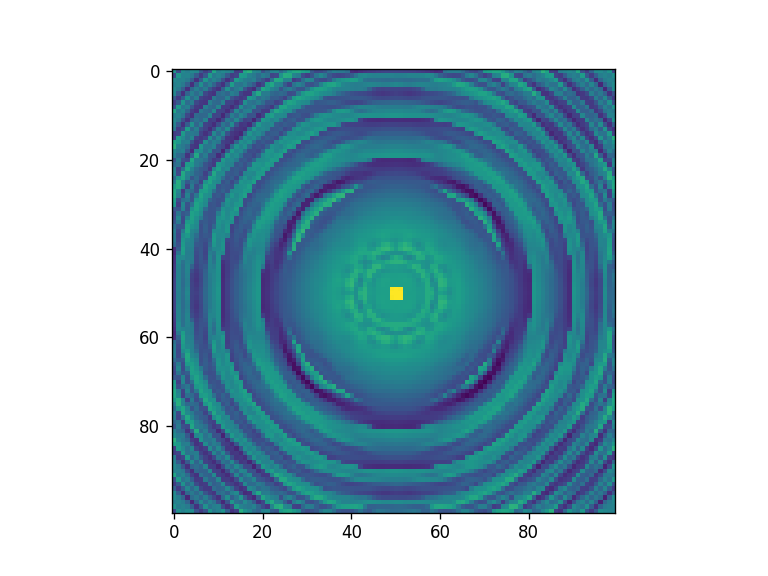

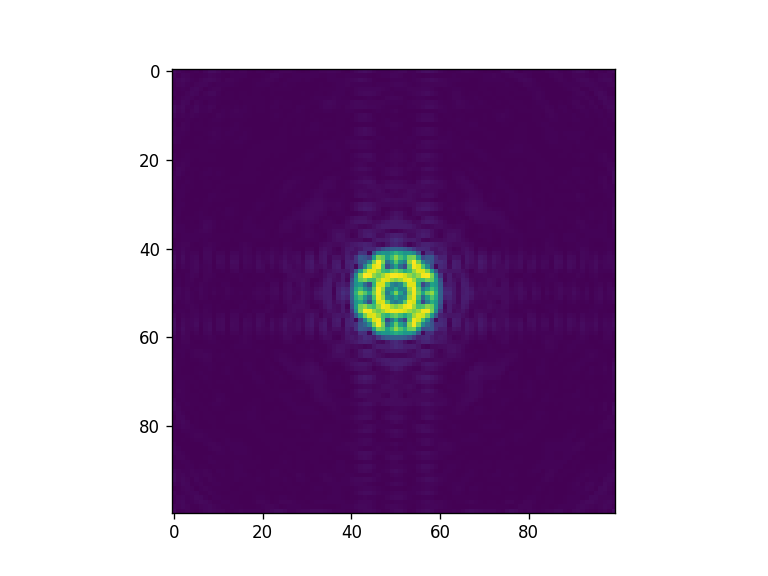

In [29]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) ) )

fig = plt.figure() 
xar2 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar, mask2, screen, wavelength) ) )


Elapsed: 0:00:00.039822
Elapsed: 0:00:00.069695
Elapsed: 0:00:00.028871
Elapsed: 0:00:00.070689
Elapsed: 0:00:00.027877
Elapsed: 0:00:00.070690
Elapsed: 0:00:00.028873
Elapsed: 0:00:00.069694
Elapsed: 0:00:00.044803
Elapsed: 0:00:00.032856
Elapsed: 0:00:00.079650
Elapsed: 0:00:00.028873
Elapsed: 0:00:00.069694
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.067724
Elapsed: 0:00:00.028874
Elapsed: 0:00:00.068699
Elapsed: 0:00:00.026908
Elapsed: 0:00:00.070690
Elapsed: 0:00:00.029867
Elapsed: 0:00:00.069695
Elapsed: 0:00:00.028872
Elapsed: 0:00:00.075669
Elapsed: 0:00:00.029869
Elapsed: 0:00:00.073677
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.067703
Elapsed: 0:00:00.027412
Elapsed: 0:00:00.068699
Elapsed: 0:00:00.027877
Elapsed: 0:00:00.068699
Elapsed: 0:00:00.045799
Elapsed: 0:00:00.101554
Elapsed: 0:00:00.027877
Elapsed: 0:00:00.070690
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.068699
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.085624
Elapsed: 0:00:00.027877
Elapsed: 0:00:00.083653
Elapsed: 0:00:00

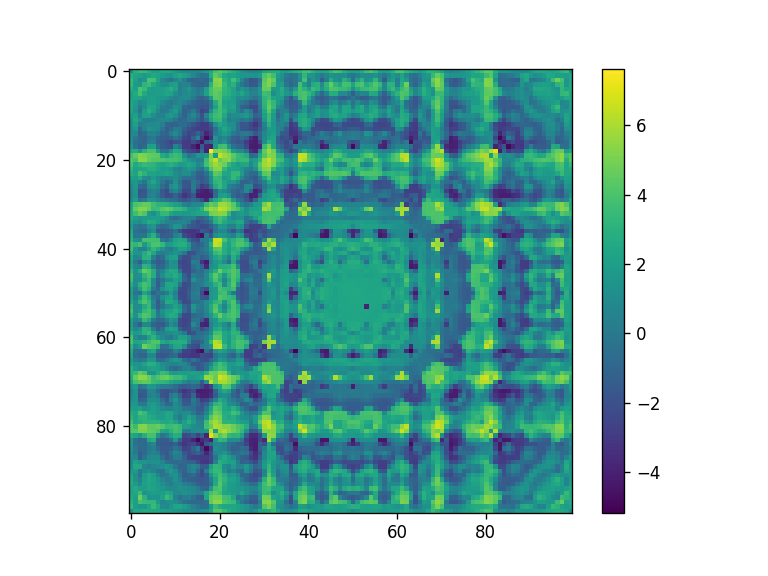

In [30]:
solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(mask2, screen, wavelength,matrix, "ASM"), optimizer_method="dogbox", verbose=0, ftol=1e-5)

x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

Elapsed: 0:00:00.014935
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.028873


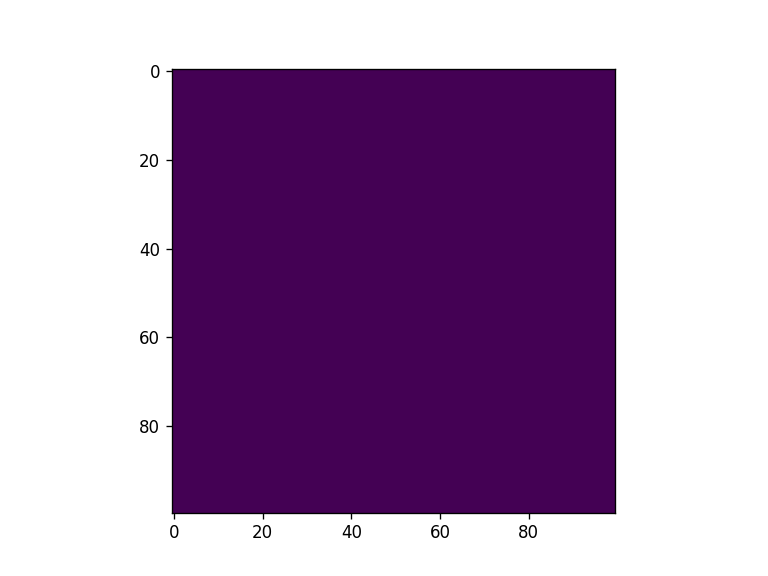

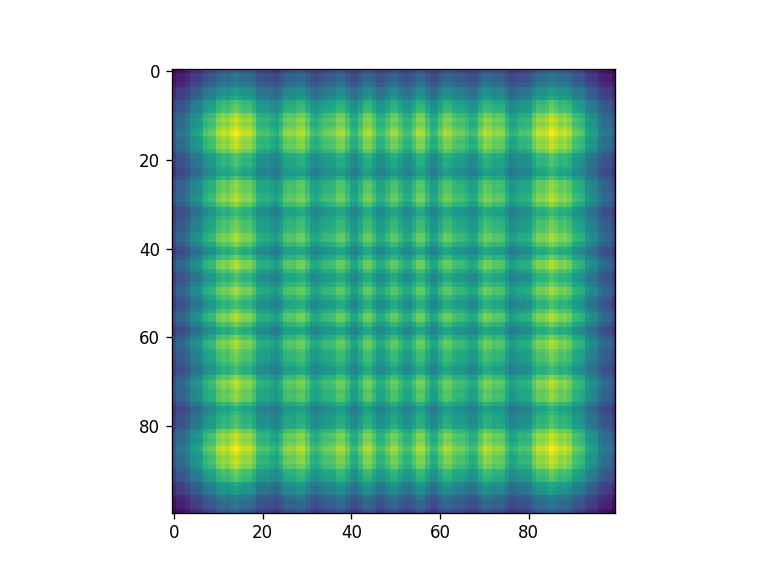

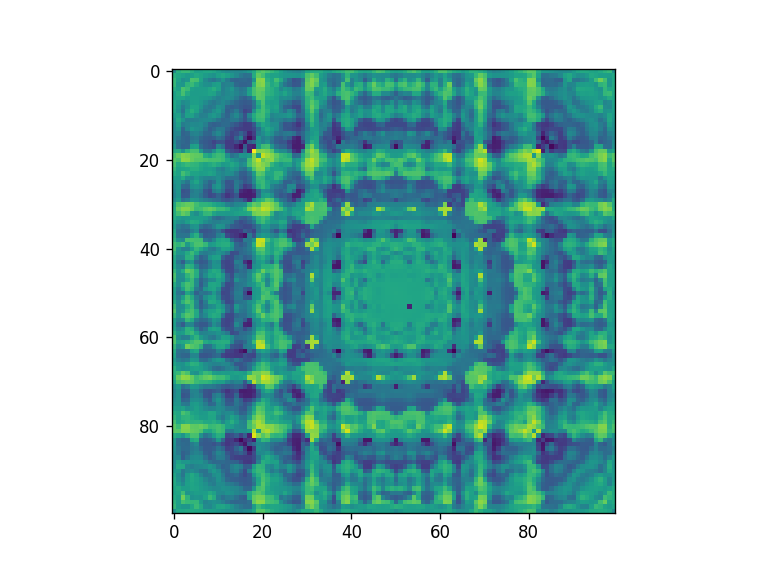

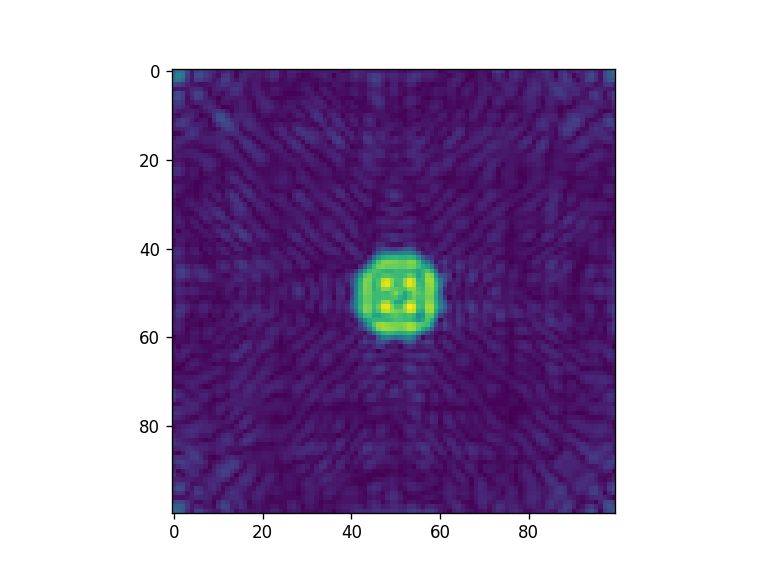

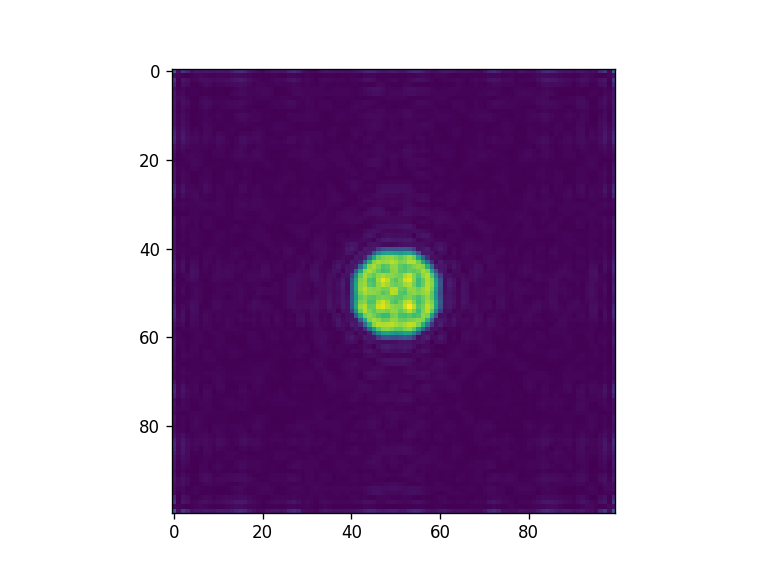

In [31]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) ) )

fig = plt.figure() 
xar2 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar, mask2, screen, wavelength) ) )

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar, mask2, screen, wavelength, propagation_method="ASM") ) )


Elapsed: 0:00:00.030820
Elapsed: 0:00:00.043762
Elapsed: 0:00:00.018919
Elapsed: 0:00:00.043807
Elapsed: 0:00:00.018918
Elapsed: 0:00:00.071715
Elapsed: 0:00:00.018916
Elapsed: 0:00:00.042813
Elapsed: 0:00:00.018918
Elapsed: 0:00:00.042812
Elapsed: 0:00:00.018917
Elapsed: 0:00:00.043804
Elapsed: 0:00:00.017922
Elapsed: 0:00:00.041817
Elapsed: 0:00:00.017922
Elapsed: 0:00:00.042811
Elapsed: 0:00:00.018917
Elapsed: 0:00:00.041816
Elapsed: 0:00:00.017922
Elapsed: 0:00:00.045799
Elapsed: 0:00:00.018917
Elapsed: 0:00:00.045798
Elapsed: 0:00:00.017921
Elapsed: 0:00:00.042812
Elapsed: 0:00:00.018916
Elapsed: 0:00:00.042834
Elapsed: 0:00:00.018917
Elapsed: 0:00:00.042812
Elapsed: 0:00:00.019913
Elapsed: 0:00:00.041817
Elapsed: 0:00:00.017921
Elapsed: 0:00:00.041816
Elapsed: 0:00:00.018916
Elapsed: 0:00:00.043809
Elapsed: 0:00:00.017922
Elapsed: 0:00:00.045799
Elapsed: 0:00:00.018917
Elapsed: 0:00:00.045799
Elapsed: 0:00:00.019913
Elapsed: 0:00:00.042842
Elapsed: 0:00:00.017921
Elapsed: 0:00:00

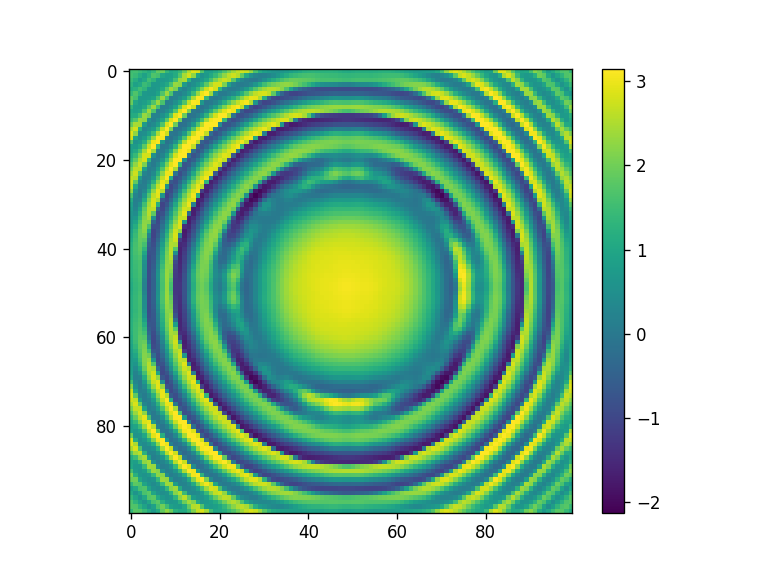

In [32]:
## Optimization with bounds 

solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(mask2, screen, wavelength, matrix, "SASM"), optimizer_method="dogbox", bounds =(-np.pi, np.pi), ftol = 1e-12 )

x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

Elapsed: 0:00:00.015930
Elapsed: 0:00:00.014935


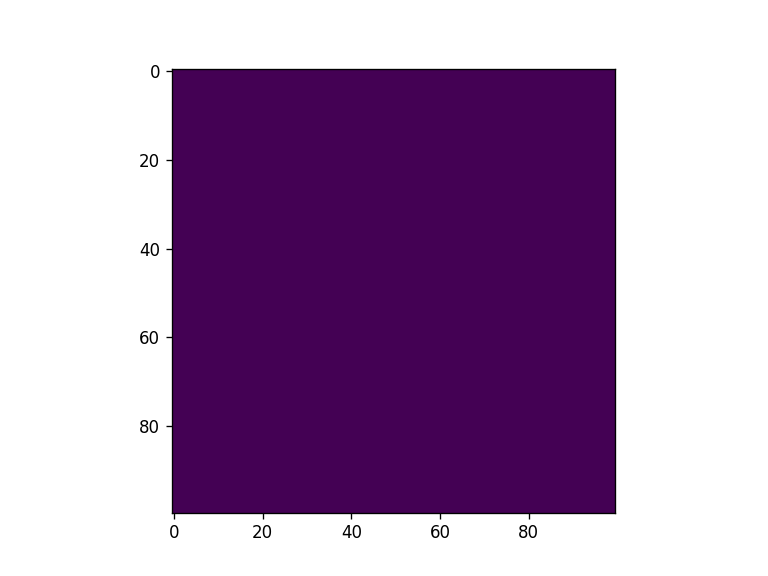

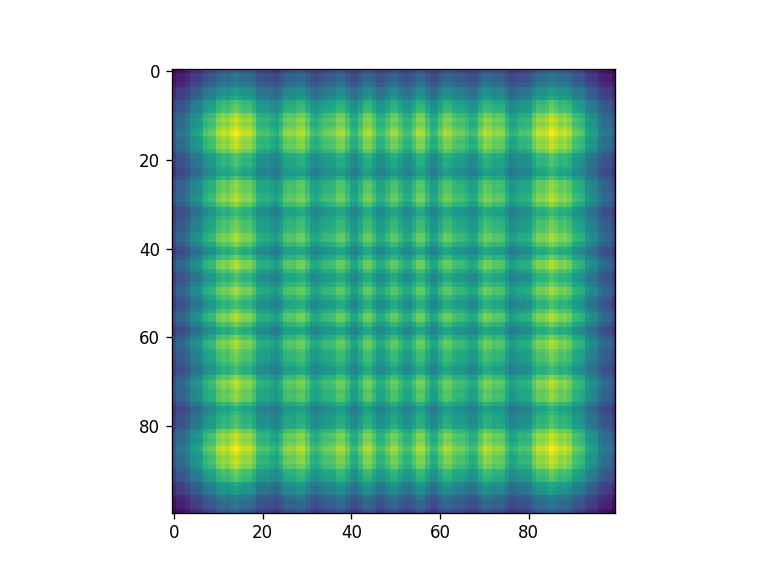

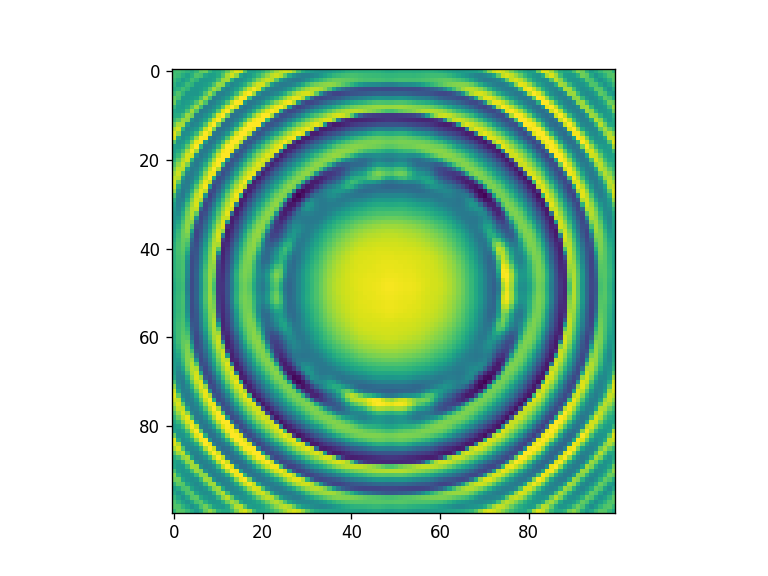

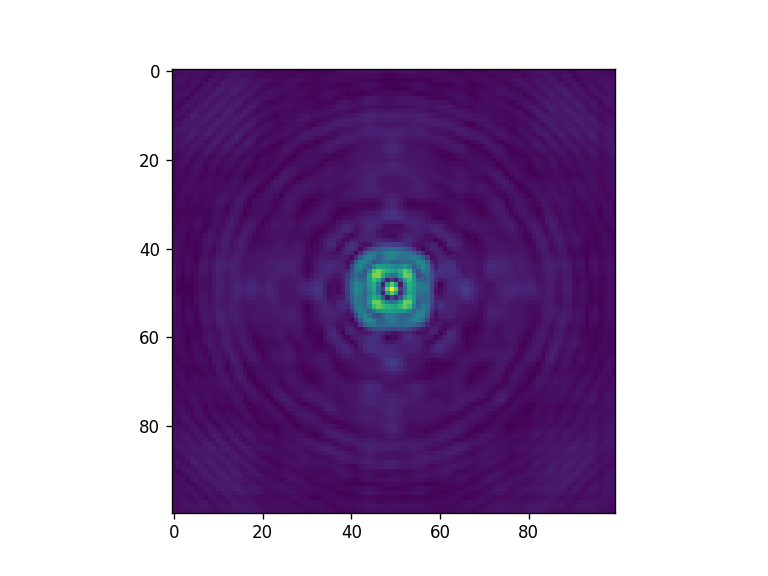

In [33]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) ) )

fig = plt.figure() 
xar2 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar, mask2, screen, wavelength) ) )


In [34]:
#Uncomment to try any of these global optimization methods 

##bounds = [(-np.pi, np.pi)]*len(x0_flatten)

##solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(mask2, screen,wavelength),  optimizer_method="dual_annealing", tol=1 , minimizer_kwargs={"args":(mask2, screen, wavelength), "tol": 1 },  bounds = bounds)

##solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(mask2, screen),  optimizer_method="basinhopping", tol=1 ,minimizer_kwargs={"args":(mask2, screen), "tol": 1 },  bounds = bounds)

##solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(mask2, screen),  optimizer_method="differential_evolution", tol=1 ,minimizer_kwargs={"args":(mask2, screen), "tol": 1 },  bounds = bounds)

## Hologram creation via inverse design

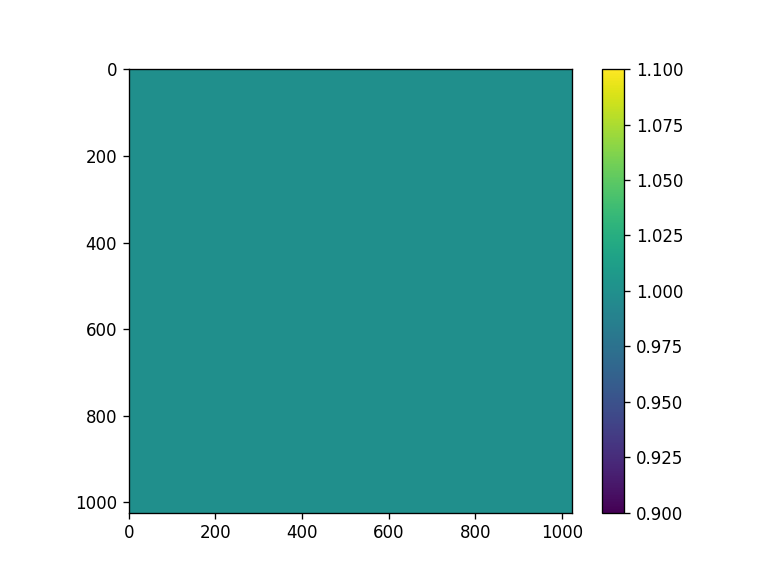

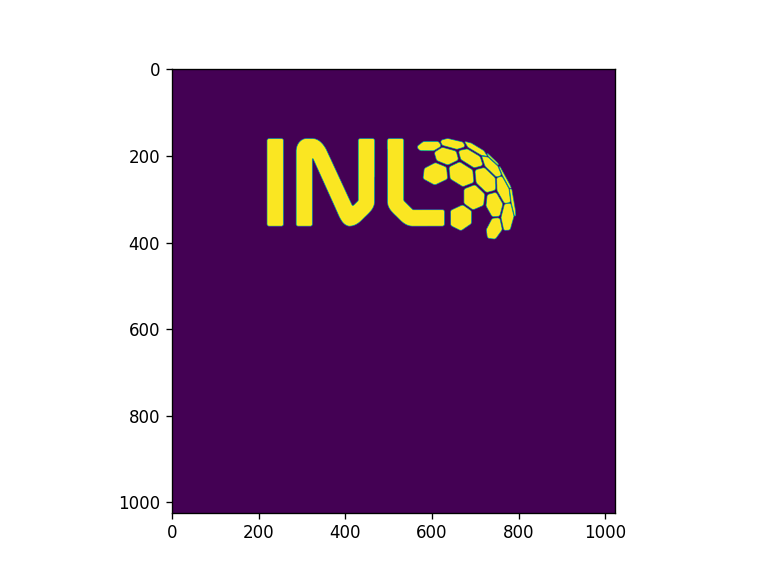

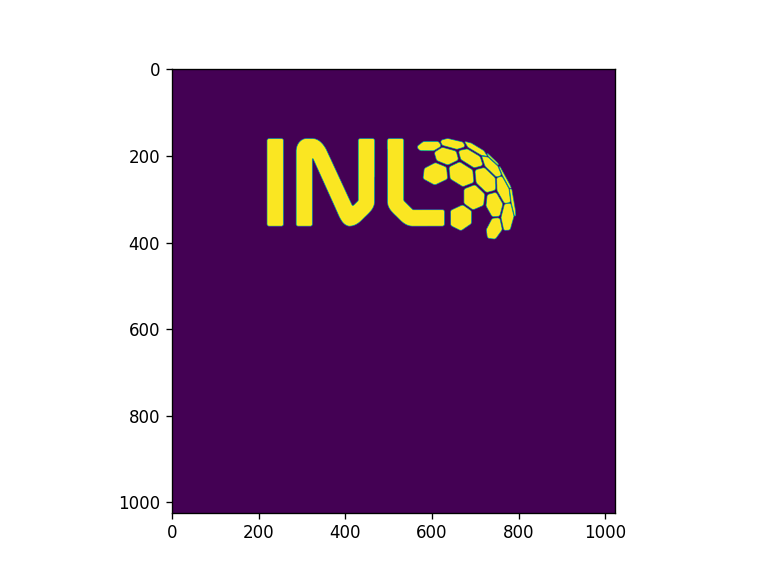

In [35]:
#Using GS first 

#Initial guess
x_pixel, y_pixel = 100, 100
matrix = plt.imread("target.png")

x_pixel, y_pixel = np.shape(matrix)
matrix_flat = matrix.flatten()

x0 = np.random.rand(x_pixel, y_pixel) 
x0 = np.ones((x_pixel,y_pixel))
#x0 = 
x0_flatten = x0.flatten()


xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi)
    

fig = plt.figure() 
plt.imshow(x0)
plt.colorbar()


fig = plt.figure() 
plt.imshow(matrix)

fig = plt.figure() 
plt.imshow(np.reshape(matrix_flat, (x_pixel, y_pixel)))

Progress: [####################] 100.0%
[Gerchberg Saxton Algorithm]
Elapsed: 0:01:08.858553


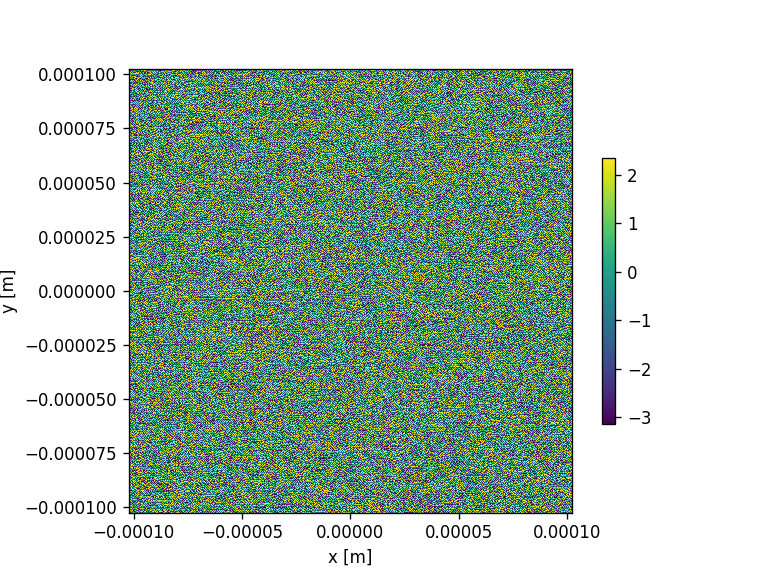

In [36]:
# Multilevel phase hologram
levels = 8

iterations = 100

levels = moe.utils.create_levels(-np.pi, np.pi, levels,)
phase_mask, errors = moe.holograms.algorithm_Gerchberg_Saxton(matrix, iterations=iterations, levels=levels)

phase_mask = moe.holograms.correct_mask_shift(phase_mask)
mask = moe.generate.create_aperture_from_array(phase_mask, pixel_size=(0.2*micro, 0.2*micro), center=True, )


# Discretize to same levels as original
mask.discretize(levels)
moe.plotting.plot_aperture(mask

In [37]:
mask.aperture

array([[-1.57079633, -0.78539816, -0.78539816, ...,  0.        ,
        -0.78539816, -1.57079633],
       [-2.35619449, -1.57079633, -2.35619449, ..., -1.57079633,
        -2.35619449, -3.14159265],
       [ 2.35619449, -3.14159265,  2.35619449, ..., -3.14159265,
         2.35619449,  1.57079633],
       ...,
       [-3.14159265, -2.35619449, -2.35619449, ..., -3.14159265,
         2.35619449,  2.35619449],
       [ 1.57079633,  2.35619449,  2.35619449, ...,  2.35619449,
         0.78539816,  1.57079633],
       [ 0.        ,  0.78539816,  0.78539816, ...,  1.57079633,
         0.        ,  0.        ]])

Text(0.5, 1.0, 'Calculated far field intensity')

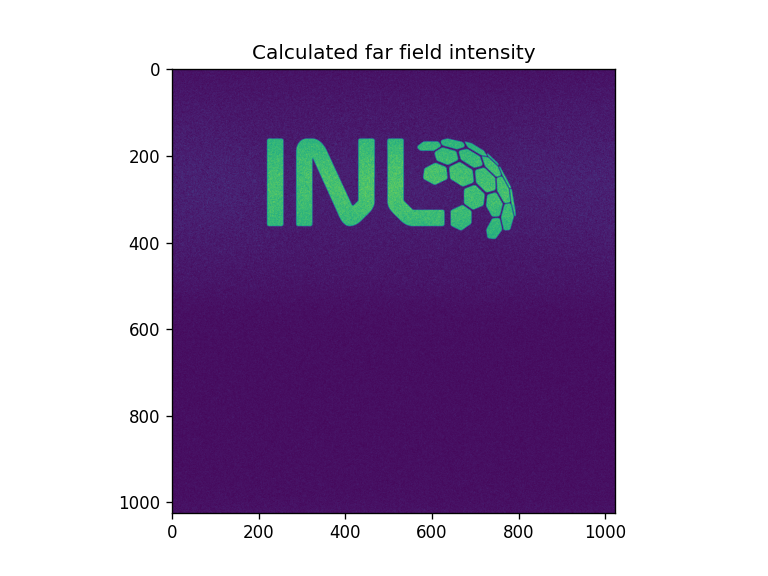

In [38]:
far_field = moe.holograms.calculate_phase_farfield(phase_mask)

plt.figure()
plt.imshow(far_field)
plt.title("Calculated far field intensity")

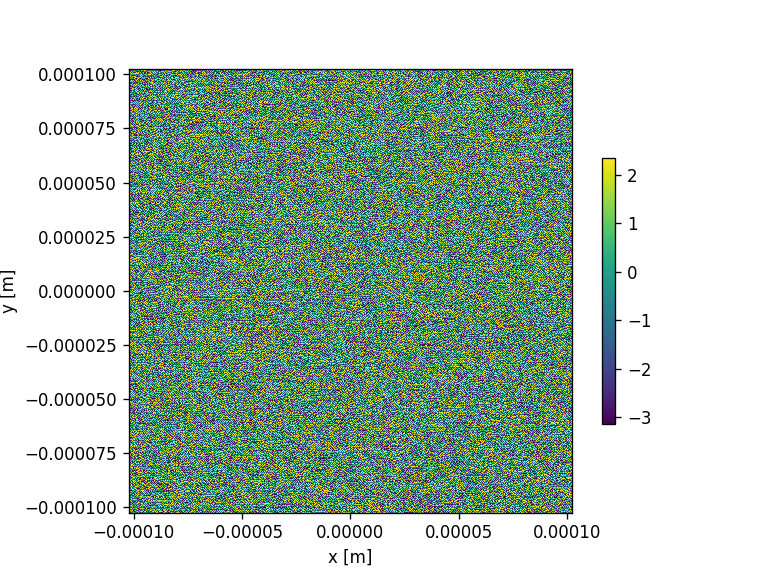

In [39]:
moe.plotting.plot_aperture(mask)

In [40]:
#Place holders for apertures 

#size of the rectangular mask 
aperture_width  = 50e-6 #m
aperture_height = 50e-6

pixsize = 1e-6 #m

wavelength = 500e-9 #m
focal_length = 200e-6

zmin = wavelength
zmax = 1.2* focal_length
nzs = 500

radius = aperture_width/2 

# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

# Populate Aperture with Fresnel mask 
mask1 = moe.generate.fresnel_phase(aperture1, focal_length, wavelength )

#moe.plotting.plot_aperture(mask1)


##############
###Fresnel mask with a truncated circular aperture 

# Create empty mask
aperture2 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)


# and truncate around radius
mask2 = moe.generate.fresnel_phase(aperture2, focal_length, wavelength, radius=radius)
#moe.plotting.plot_aperture(mask2)

# Discretize mask in number of levels
# Select exact position of contours  in phase
phase_vals = np.linspace(-np.pi, np.pi, 16)

mask2.discretize(np.array( phase_vals)[:] ) 
#moe.plotting.plot_aperture(mask2)

# Generate a uniform field
field = moe.field.create_empty_field_from_aperture(mask2)

field = moe.field.generate_uniform_field(field, E0=1)

# Modulates the field 
field = moe.field.modulate_field(field, amplitude_mask=None, phase_mask=mask2 )


# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

# Populate Aperture with Fresnel mask 
mask2 = moe.generate.fresnel_phase(aperture1, focal_length, wavelength )

#moe.plotting.plot_aperture(mask2)

In [41]:
#Define Screen 

# define the wavelength used in the propagation
wavelength = 532*nano

# Define the screen size and create it

screen_width = 2.5
screen_height = 2.5
x_pixel = 1024
y_pixel = 1024


# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -screen_height/2, screen_height/2
xmin, xmax = -screen_width/2, screen_width/2 

s=0.1

x = np.linspace(xmin*s, xmax*s, x_pixel)
y = np.linspace(ymin*s, ymax*s, y_pixel)
z = np.array([2*s])


screen = moe.field.Screen(x,y,z)

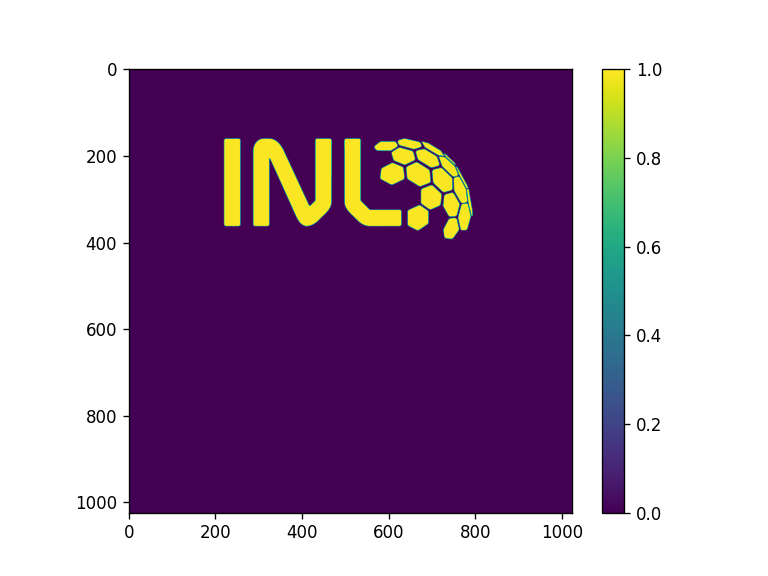

In [42]:

fig = plt.figure() 
plt.imshow(matrix)
plt.colorbar()

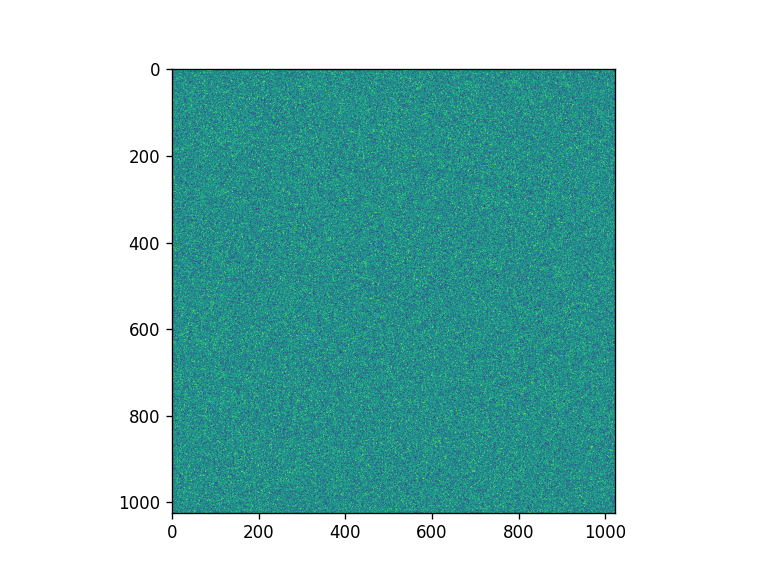

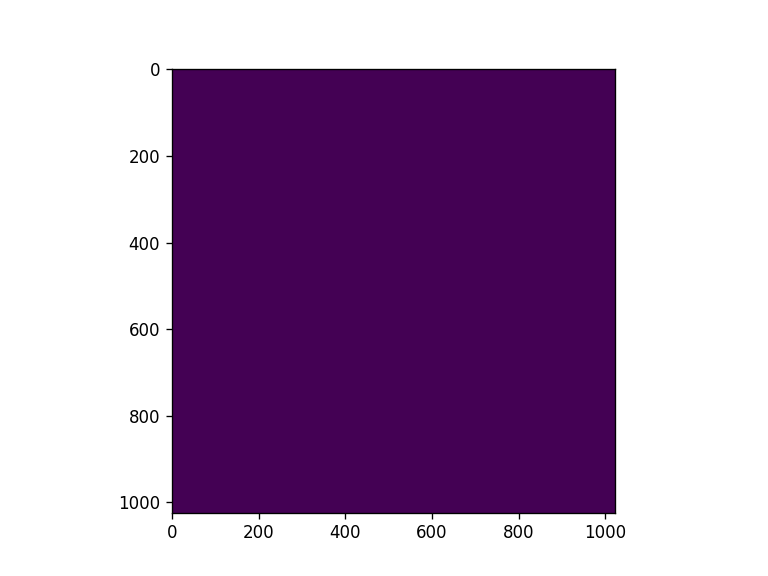

In [43]:
# generation of initial guesses, 

#random 
xrand = np.random.rand(x_pixel, y_pixel)

plt.figure() 
plt.imshow(xrand)

#constant 
xvalues = np.ones((x_pixel, y_pixel))

plt.figure()
plt.imshow(xvalues)
#plt.colorbar()

In [44]:
def FOM3(x, mask, screen, wavelength, mat, propag="bluestein", pad=2): 
    #print("Type of x:", type(x), "First element:", x[0])
    #print("Type of x:", type(mask))
    #print("Type of x:", type(screen), "First element:", x[0])
    #print("Type of x:", type(wavelength), "First element:", x[0])
    import jax.numpy as np 
    
    prop_x =  np.abs(moe.optimizer.propagate(np.reshape(x, (len(screen.x), len(screen.y))), mask, screen, wavelength,\
                                             propagation_method=propag, pad_factor=pad))**2
    
    #diff = np.abs(prop_x - mat/np.max(mat)*np.max(prop_x))**2
    diff = np.abs(prop_x/np.max(prop_x) - mat/np.max(mat))**2
     
    #print(diff.shape)
    #jax.debug.print(str(np.max(diff))+"  "+str(np.max(prop_x))+" "+str(np.min(prop_x)) )
    
    #res = (np.sqrt(np.sum(diff)) )
    res = np.sum(diff)
    #print(res)

    
    #jax.debug.print(f"{res}")
    
    return res

Elapsed: 0:00:01.906674
Elapsed: 0:00:01.374763
Elapsed: 0:00:00.566389
Elapsed: 0:00:00.798518
Elapsed: 0:00:00.581856
Elapsed: 0:00:00.752236
Elapsed: 0:00:00.577306
Elapsed: 0:00:00.743652
Elapsed: 0:00:00.561534
Elapsed: 0:00:00.751729
Elapsed: 0:00:00.570498
Elapsed: 0:00:00.756191
Elapsed: 0:00:00.587421
Elapsed: 0:00:00.713906
Elapsed: 0:00:00.577495
Elapsed: 0:00:00.769167
Elapsed: 0:00:00.607338
Elapsed: 0:00:00.738799
Elapsed: 0:00:00.566513
Elapsed: 0:00:00.748713
Elapsed: 0:00:00.604854
Elapsed: 0:00:00.757746
Elapsed: 0:00:00.559113
Elapsed: 0:00:00.718897
Elapsed: 0:00:00.568524
Elapsed: 0:00:00.757289
Elapsed: 0:00:00.592437
Elapsed: 0:00:00.565583
Elapsed: 0:00:00.569499
Elapsed: 0:00:00.755728
Elapsed: 0:00:00.567512
Elapsed: 0:00:00.763175
Elapsed: 0:00:00.586944
Elapsed: 0:00:00.741846
Elapsed: 0:00:00.594782
Elapsed: 0:00:00.745761
Elapsed: 0:00:00.609410
Elapsed: 0:00:00.720858
Elapsed: 0:00:00.594816
Elapsed: 0:00:00.784642
Elapsed: 0:00:00.596843
Elapsed: 0:00:00

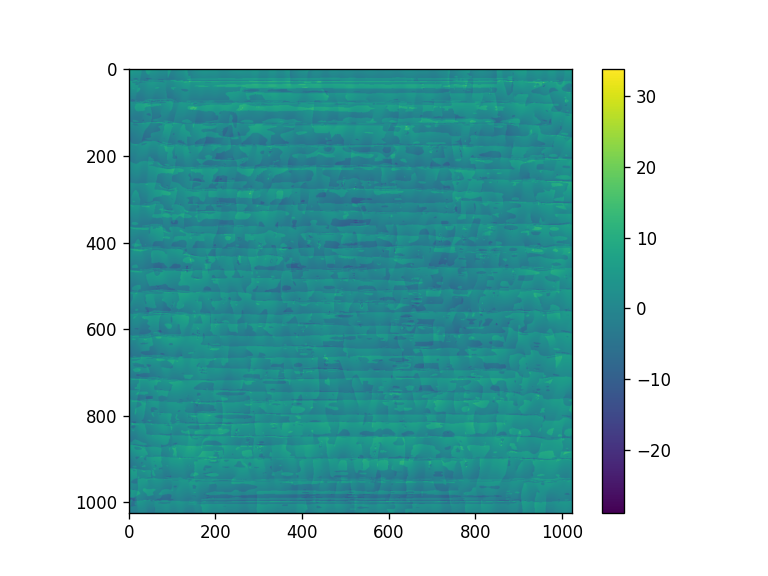

In [45]:
solution = moe.optimizer.optimize(FOM3, x0= xvalues.flatten(), args1=[mask2, screen, wavelength, matrix], verbose = 1, ftol=1e-6, xtol=None,\
                                  optimizer_method='dogbox' )


x2 = solution.x

fig = plt.figure() 
xar = np.reshape(x2, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

Elapsed: 0:00:00.581285
Elapsed: 0:00:00.586358


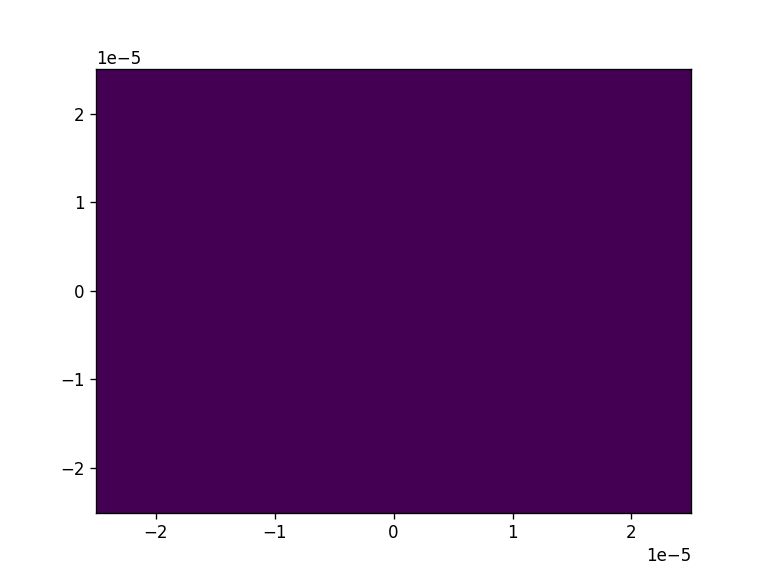

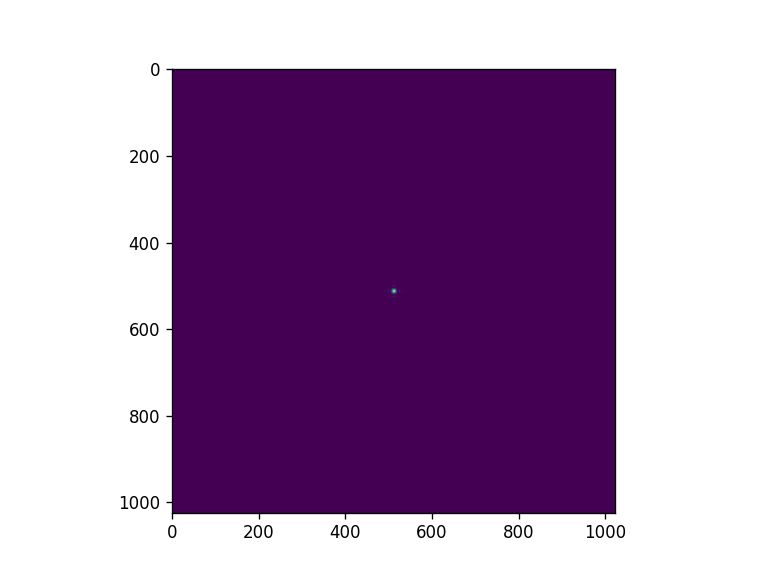

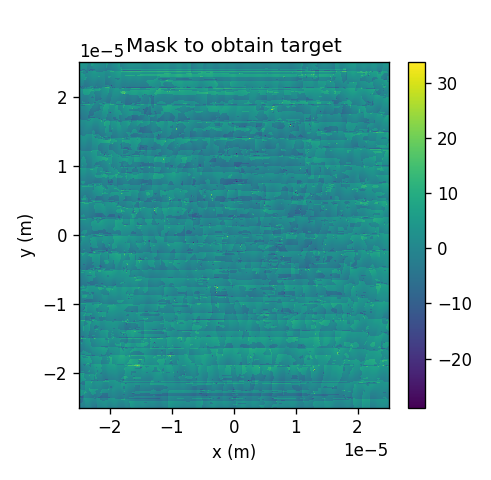

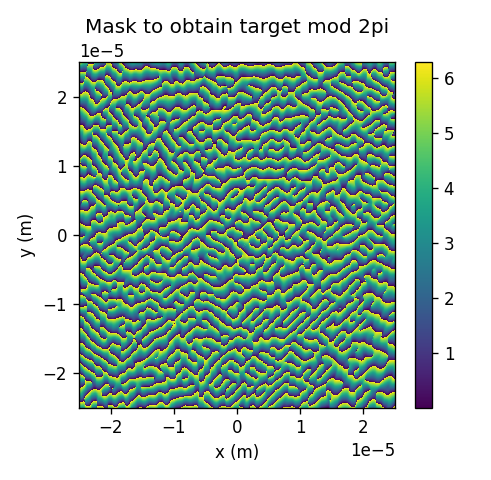

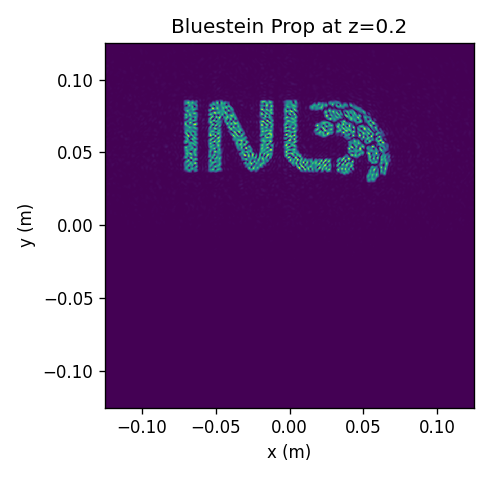

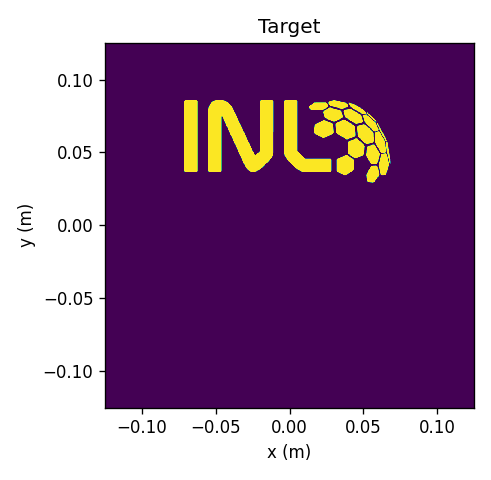

In [46]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
#plt.imshow(xar2) 
plt.pcolormesh(mask2.x, mask2.y, xar2)

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) )**2 )


fig = plt.figure(figsize=(4.1,4)) 
xar3 = np.reshape(x2, (x_pixel, y_pixel))
plt.pcolormesh(mask2.x, mask2.y, np.flip(np.flip(xar3), axis=1)) 
plt.title("Mask to obtain target")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.colorbar()
plt.tight_layout()




fig = plt.figure(figsize=(4.1,4)) 
xar3 = np.reshape(x2, (x_pixel, y_pixel))
plt.pcolormesh(mask2.x, mask2.y, np.flip(np.flip(xar3)%(2*np.pi), axis=1)) 
plt.title("Mask to obtain target mod 2pi")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.colorbar()
plt.tight_layout()



fig = plt.figure(figsize=(4.1,4)) 
plt.pcolormesh(screen.x, screen.y, np.flip(np.flip(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength) )**2 ) , axis=1))
plt.title("Bluestein Prop at z="+str(screen.z[-1]))
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()

fig = plt.figure(figsize=(4.1,4)) 
plt.pcolormesh(screen.x,screen.y, np.flip(np.flip(np.reshape(matrix, (x_pixel, y_pixel)) ) ,axis =1))
plt.title("Target")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()

# Now we introduce several possible metrics 

In [122]:
# These metrics could be used to build specific loss functions 

In [156]:
#size of the rectangular mask 
aperture_width  = 50e-6 #m
aperture_height = 50e-6

pixsize = 1e-6 #m

wavelength = 500e-9 #m
focal_length = 200e-6

zmin = wavelength
zmax = 1.2* focal_length
nzs = 500

radius = aperture_width/2 

# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

# Populate Aperture with Fresnel mask 
mask1 = moe.generate.fresnel_phase(aperture1, focal_length, wavelength )

#moe.plotting.plot_aperture(mask1)


##############
###Fresnel mask with a truncated circular aperture 

# Create empty mask
aperture2 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)


# and truncate around radius
mask2 = moe.generate.fresnel_phase(aperture2, focal_length, wavelength, radius=radius)
#moe.plotting.plot_aperture(mask2)

# Discretize mask in number of levels
# Select exact position of contours  in phase
phase_vals = np.linspace(-np.pi, np.pi, 16)

mask2.discretize(np.array( phase_vals)[:] ) 
#moe.plotting.plot_aperture(mask2)

# Generate a uniform field
field = moe.field.create_empty_field_from_aperture(mask2)

field = moe.field.generate_uniform_field(field, E0=1)

# Modulates the field 
field = moe.field.modulate_field(field, amplitude_mask=None, phase_mask=mask2 )


# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

# Populate Aperture with Fresnel mask 
mask2 = moe.generate.fresnel_phase(aperture1, focal_length, wavelength )

Elapsed: 0:00:01.205280


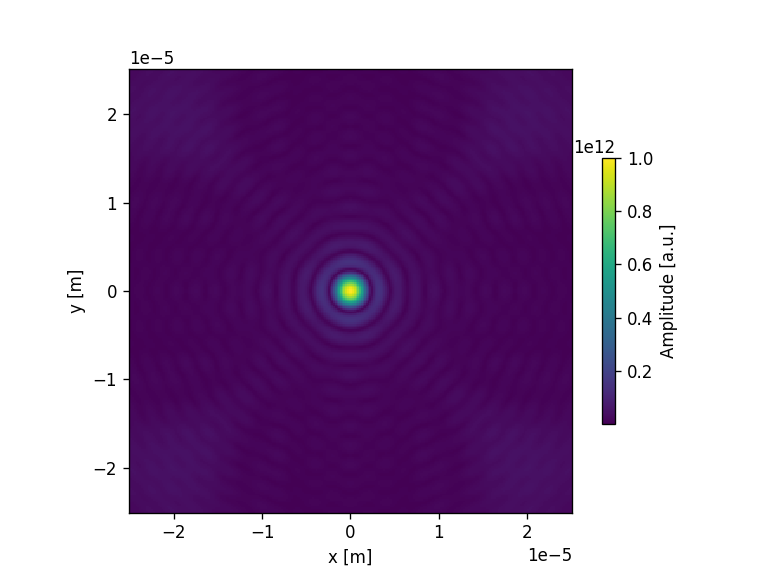

In [157]:
###Propagate field *10and calculate in plane YZ, using npix bins in Y
zmin = wavelength*10
zmax = 1.2* focal_length
nzs = 25

# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

x_pixel, y_pixel = 256, 256

x = np.linspace(xmin, xmax, x_pixel )
y = np.linspace(ymin, ymax, y_pixel )
z = np.linspace(zmin, zmax, nzs)


screen = moe.field.Screen(x,y,z)
sfreq = moe.metrics.spatial_freq_space(screen)
# Propagate the field 
EXYZ = moe.propagate.Bluestein(field, screen, wavelength)

Exy = moe.field.Screen(x,y,z)
Exy.screen = np.reshape(EXYZ.screen[:,:, int(focal_length/zmax*nzs)], (x_pixel,y_pixel,1))

moe.plotting.plot_screen_XY(Exy, which='amplitude')

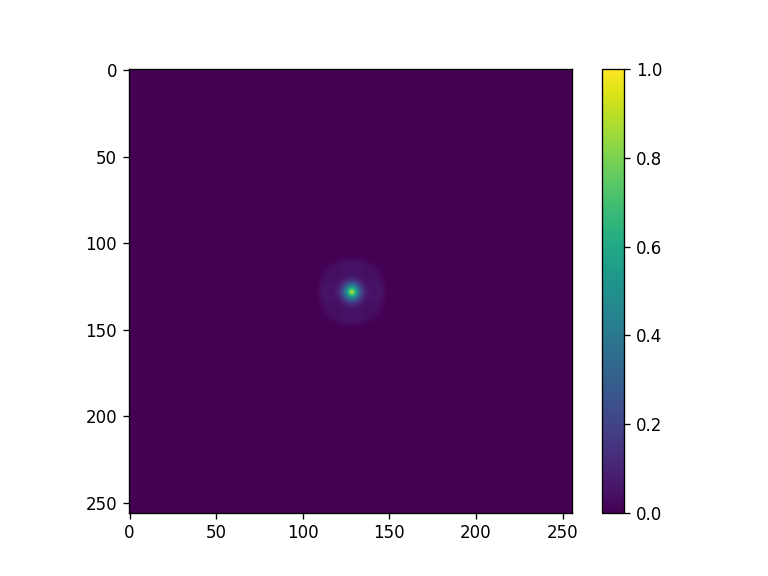

In [158]:
intensity = np.abs(screen.screen[:,:,-1])**2
#intensity = np.abs(Escreen)**2
norm_intensity = intensity/np.max(intensity)  # normalize intensity, not field

otf = sfft.fftshift(sfft.fft2(sfft.ifftshift(norm_intensity)))

center = (otf.shape[0] // 2, otf.shape[1] // 2)
otf_norm =  otf/np.abs(otf[center])


fig = plt.figure() 

plt.imshow( np.abs(otf_norm) )
plt.colorbar()

plt.show()

fig.savefig("OTF.png")



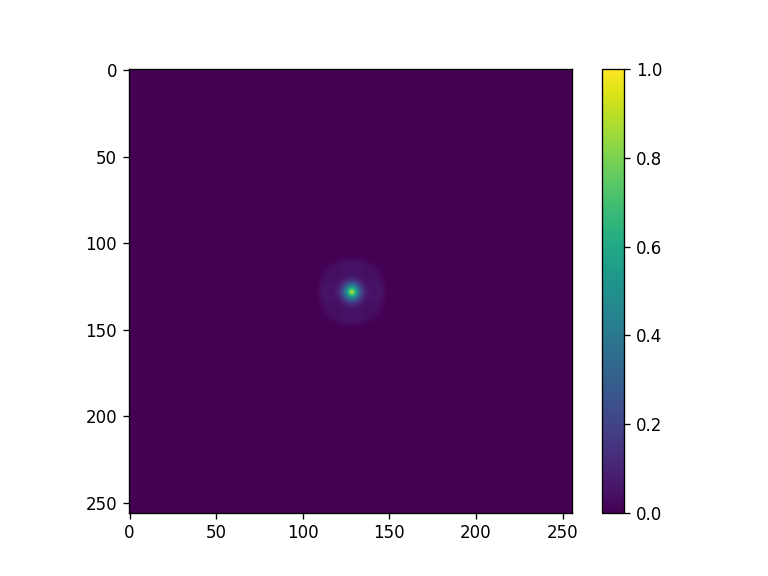

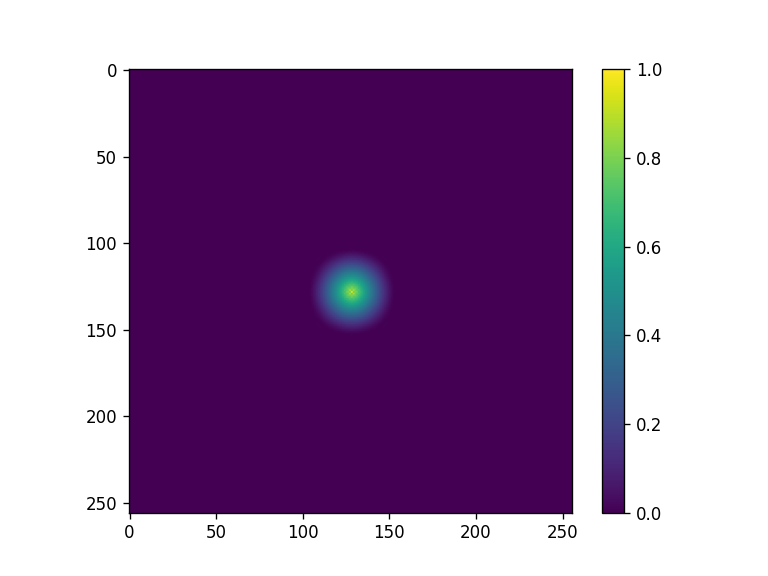

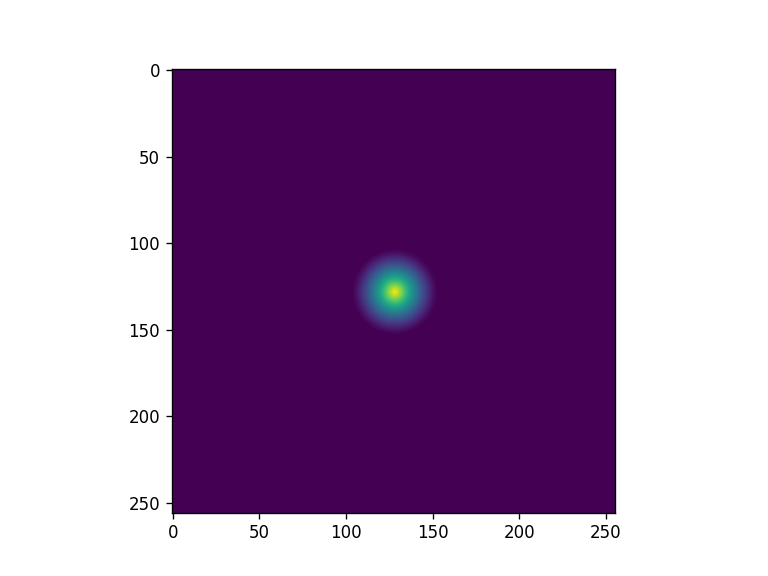

In [159]:
#Calculate the OTF out of focus and in focus 
import scipy.fftpack as sfft

o1 = moe.metrics.calculate_OTF(np.abs(screen.screen[:,:,-1])**2 , plot_OTF=True);
o2 = moe.metrics.calculate_OTF(np.abs(Exy.screen[:,:,-1])**2  , plot_OTF=True);

D = np.max(Exy.x)*2
OTF_ideal = moe.metrics.theoretical_ideal_OTF(Exy, D, wavelength, focal_length)

fig = plt.figure()
plt.imshow( OTF_ideal)

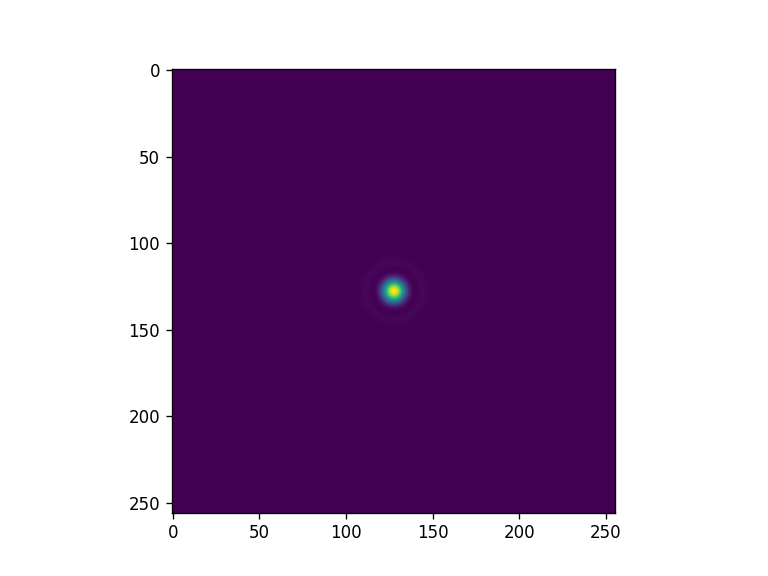

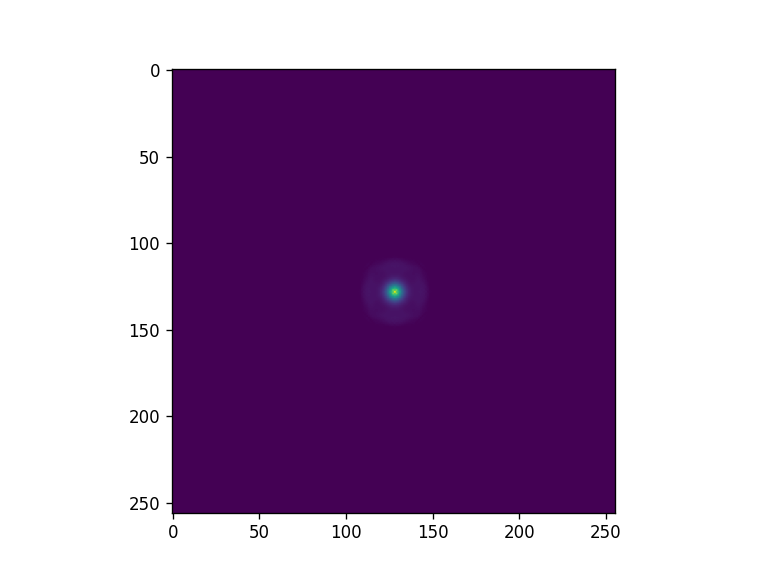

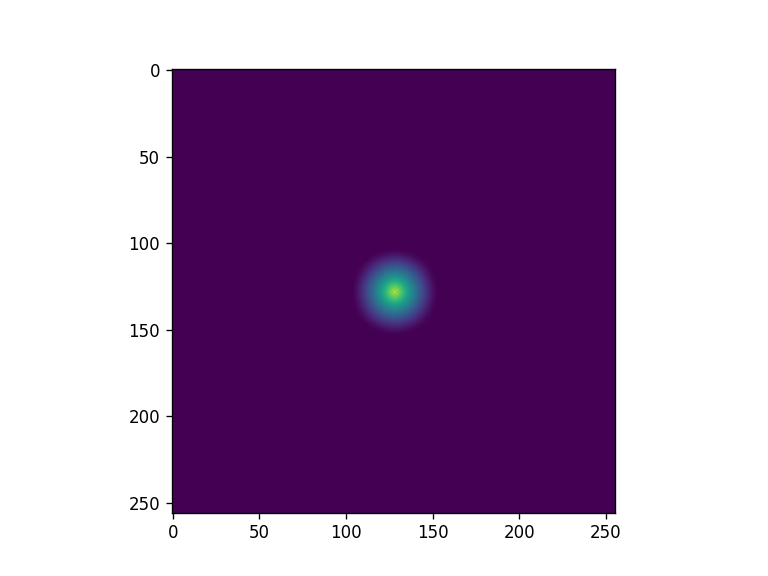

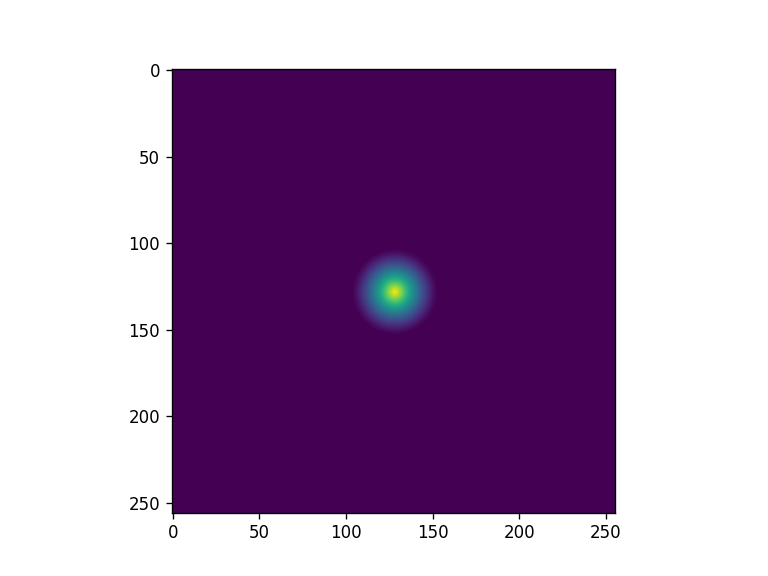

In [160]:
plt.figure() 

plt.imshow(np.abs(Exy.screen)**2) 

plt.figure()

plt.imshow(np.abs(o1) )

plt.figure()

plt.imshow(np.abs(o2) )

plt.figure()
plt.imshow(np.abs(OTF_ideal) )

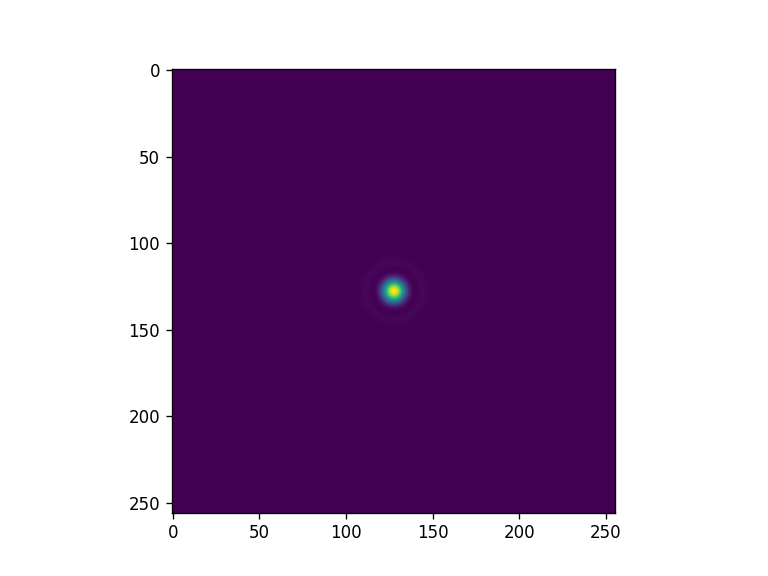

In [161]:
max([max(Exy.x), max(Exy.y)])
Exy.z[0]


fig = plt.figure() 
plt.imshow(np.abs(Exy.screen)**2)

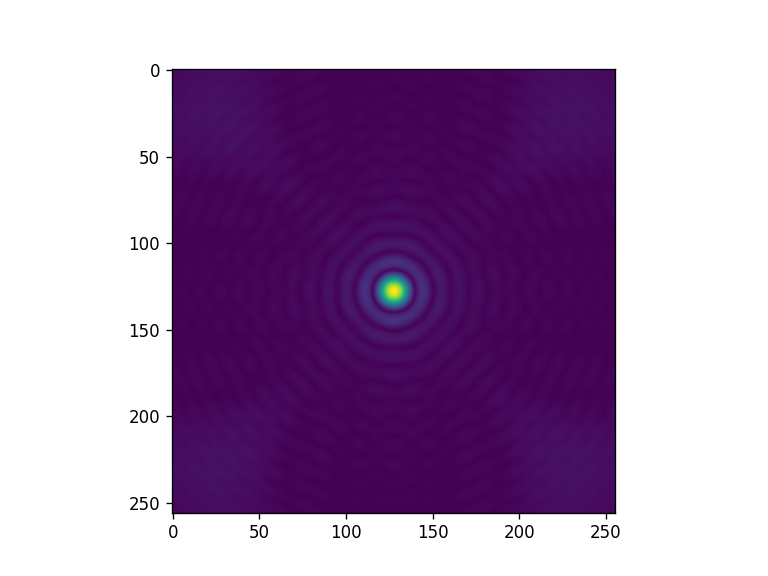

In [162]:
fig= plt.figure() 
plt.imshow(np.abs(Exy.screen) )

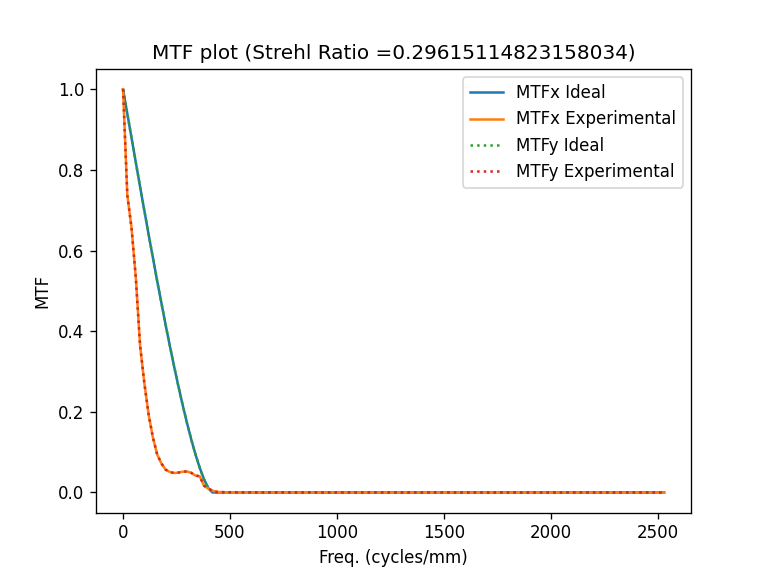

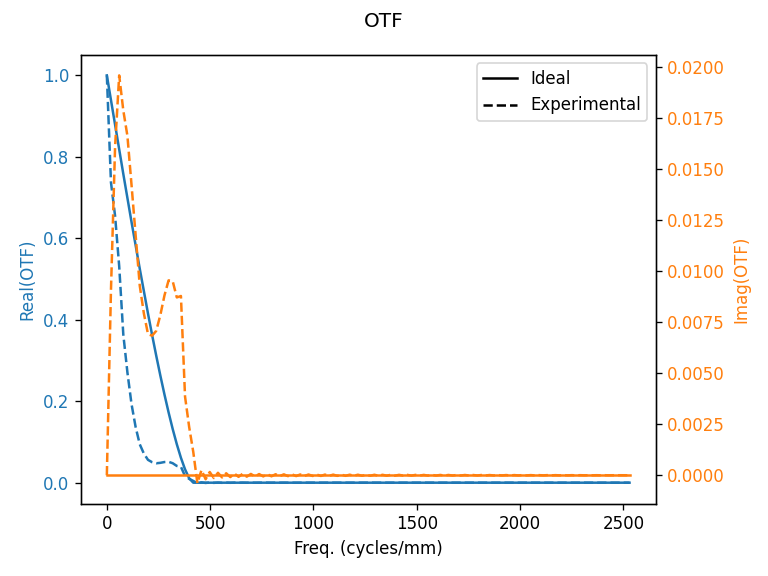

In [163]:
# MTF and OTF at DEFOCUSED PLANE 

strehlv1 = moe.metrics.strehl_ratio(np.abs(screen.screen[:,:,-1] )**2, screen, max([max(Exy.x), max(Exy.y)])*2, wavelength, screen.z[-1], strehl_from_mtf=True, plot_MTF=True, plot_OTF=True) 


(np.float64(0.29615114823158034), np.float64(0.9011953763298147))

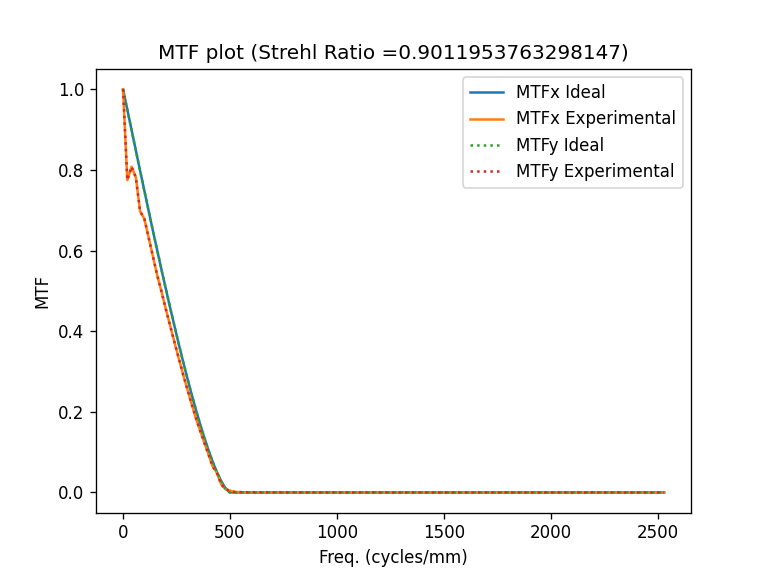

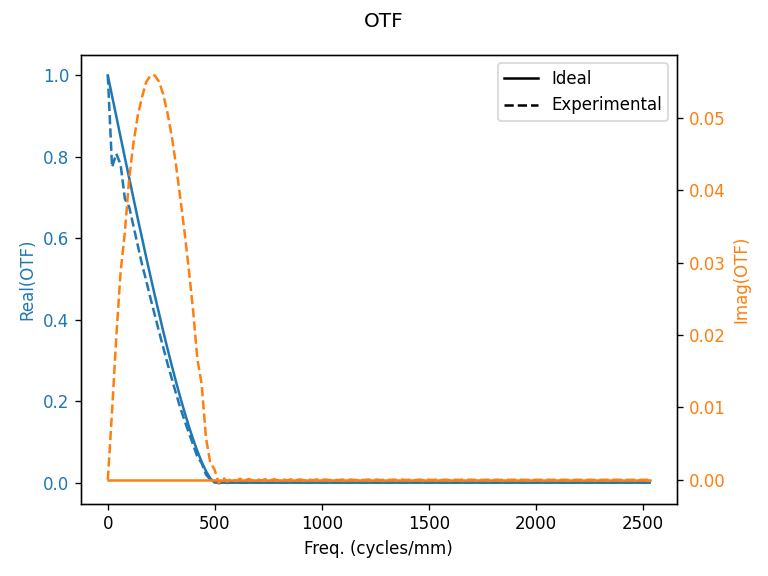

In [164]:
# MTF and OTF at FOCUSED PLANE

strehlv2 = moe.metrics.strehl_ratio(np.abs(Exy.screen[:,:,-1] )**2, Exy, max([max(Exy.x), max(Exy.y)])*2, wavelength, focal_length, strehl_from_mtf=True, plot_MTF=True, plot_OTF=True )

strehlv1, strehlv2

(np.float64(0.8879606630471453), np.float64(0.8879606630471453))

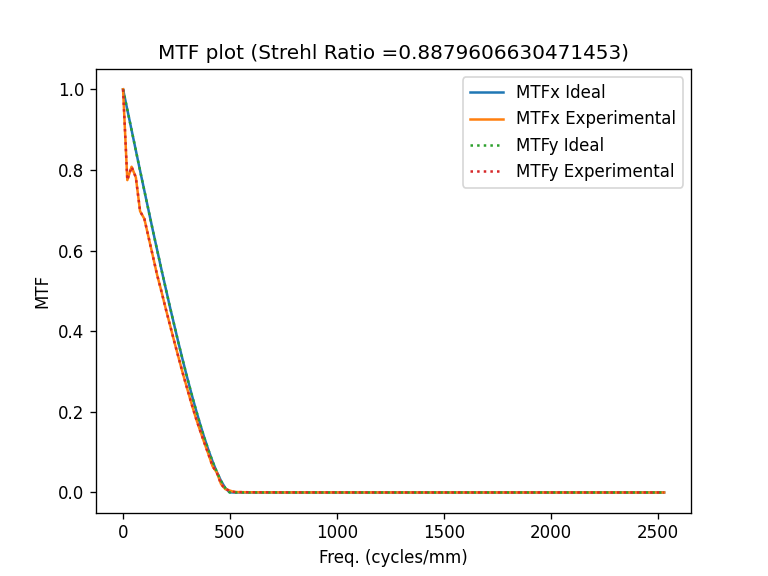

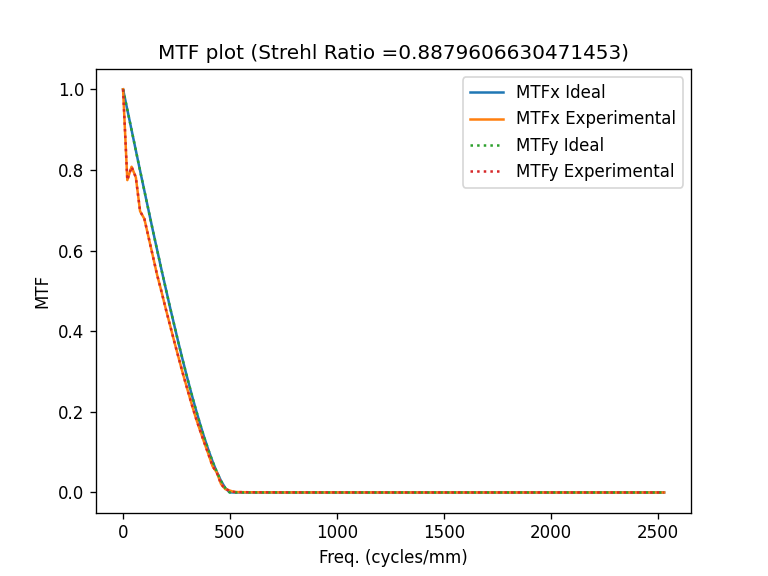

In [165]:
moe.metrics.strehl_ratio(np.abs(Exy.screen[:,:,-1])**2, screen, max([max(screen.x), max(screen.y)])*2, wavelength, focal_length, plot_MTF=True) ,\
moe.metrics.strehl_ratio(np.abs(Exy.screen[:,:,-1])**2, Exy, max([max(Exy.x), max(Exy.y)])*2, wavelength, focal_length, plot_MTF=True) 


Text(0.5, 1.0, 'Encircled energy')

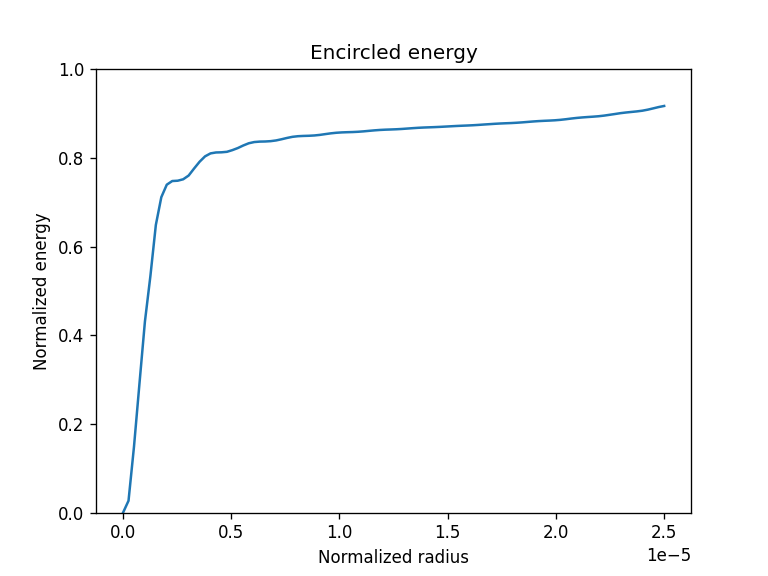

In [166]:
center=(0,0)

parray = np.linspace(0, aperture_width/2, 100)

enarray = [moe.metrics.encircled_energy(Exy, p) for p in parray]
enmax = moe.metrics.encircled_energy(Exy, 1.01)

fig = plt.figure() 

plt.plot(parray, enarray/enmax)
plt.ylim([0,1])
plt.xlabel("Normalized radius")
plt.ylabel("Normalized energy")
plt.title("Encircled energy")
#plt.yscale("log")

#This is not exactly one, because other energy is lost to the square parts of the sensor 


#The energy plateus at 0.5e-6, so makes sense to use that as p 

In [167]:
XY=np.abs(Exy.screen[:,:,-1])**2


largestpeak_height , largestpeak_width, position = moe.metrics.find_FWHM_2d(XY, prominence=0.5)

largestpeak_height , largestpeak_width, position

(np.float64(1.0007365335316455e+23),
 np.float64(17.734210609893083),
 array([127, 127]))

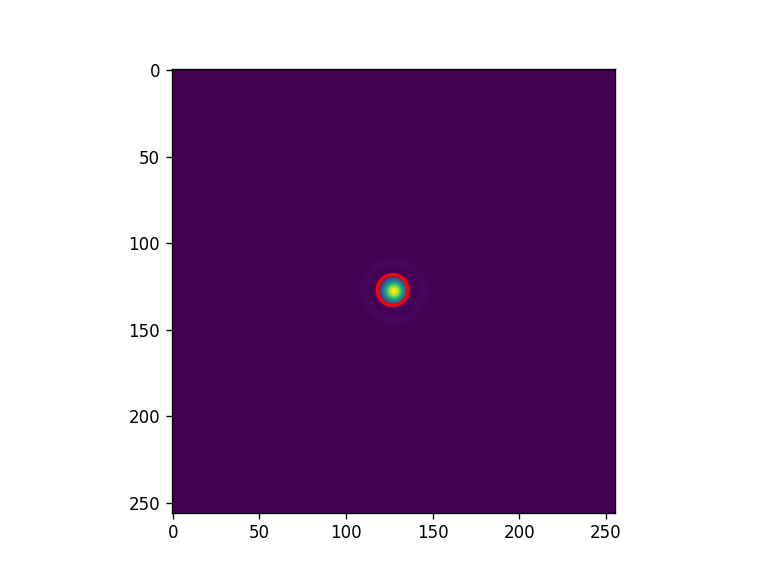

In [168]:
from matplotlib.patches import Circle 

fig = plt.figure() 

plt.imshow(np.abs(XY))

# Get image dimensions
height, width = XY.shape

# Add central circle
circle = Circle((position[0], position[1]), radius=largestpeak_width/2, color='red', fill=False, linewidth=2)
plt.gca().add_patch(circle)

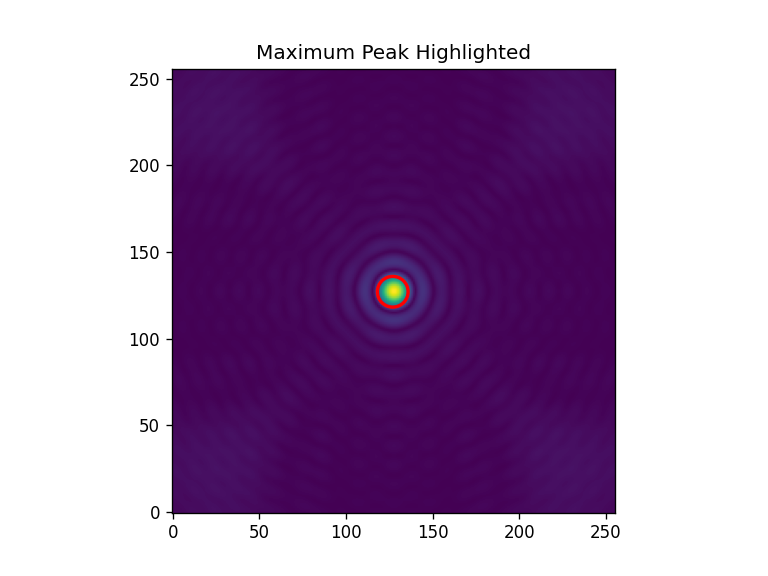

In [169]:
largestpeak_height , largestpeak_width, largestpeak_position = moe.metrics.find_FWHM_2d(np.abs(Exy.screen[:,:,-1])**2, prominence=0.5)


from matplotlib.patches import Circle

fig, ax = plt.subplots()
ax.imshow(np.abs(Exy.screen[:,:,-1]),  origin='lower')

# Draw the circle
circle = Circle((largestpeak_position[0], largestpeak_position[1]),  # x, y
                radius=largestpeak_width/2, color='red', fill=False, linewidth=2)
ax.add_patch(circle)

# Optional: mark the center
#ax.plot(largestpeak_position[0], largestpeak_position[1], 'ro')  # center dot

plt.title("Maximum Peak Highlighted")
plt.show()

In [170]:
##encircled energy at 1 FWHM 

one_fwhm = moe.metrics.encircled_energy(Exy, (width/2)*pixsize)/moe.metrics.encircled_energy(Exy, 1.01)

##encircled energy at 0.5 FWHM 

half_fwhm = moe.metrics.encircled_energy(Exy, (width/2)*pixsize*0.5)/moe.metrics.encircled_energy(Exy, 1.01)


(width/2)*pixsize, one_fwhm, half_fwhm 
#This is consistent with the plateauing that is seen in the encircled energy 

(0.000128, np.float64(1.0), np.float64(1.0))

Text(0.5, 1.0, 'Focusing Efficiency')

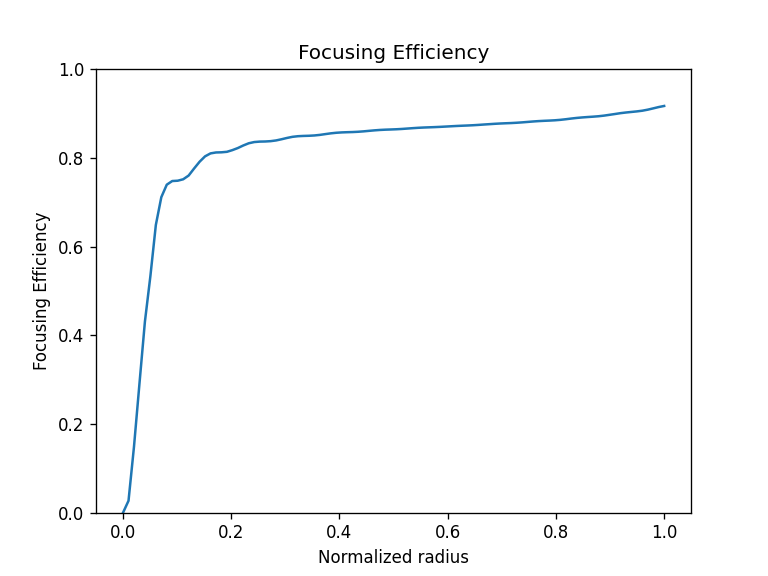

In [171]:
center=(0,0)

parray = np.linspace(0, aperture_width/2, 100)

#Should give the same as the enclircled energy 
farray1 = [moe.metrics.focus_efficiency(Exy, p,  encircled_energy(Exy, 1.01),center=(0,0),) for p in parray]

fig = plt.figure() 

plt.plot(parray/(aperture_width/2), farray1)
plt.ylim([0,1])
plt.xlabel("Normalized radius")
plt.ylabel("Focusing Efficiency")
plt.title("Focusing Efficiency")
#plt.yscale("log")


Text(0.5, 1.0, 'Engelberg OPM')

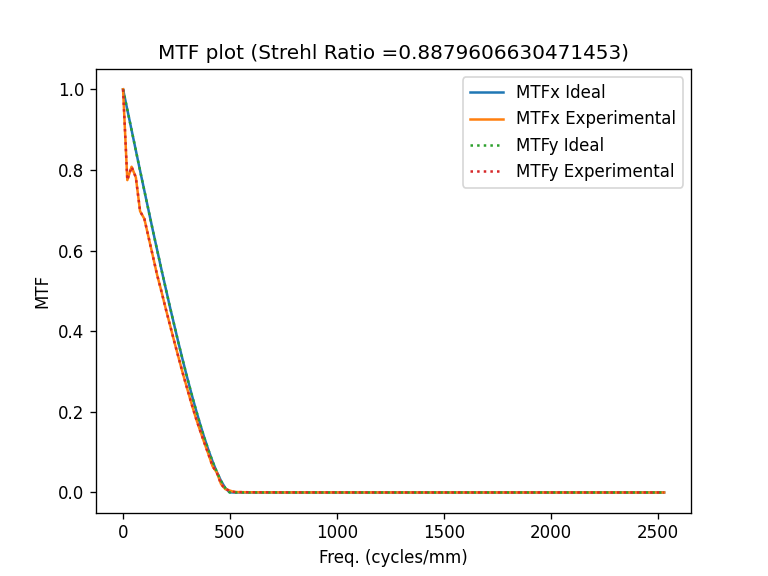

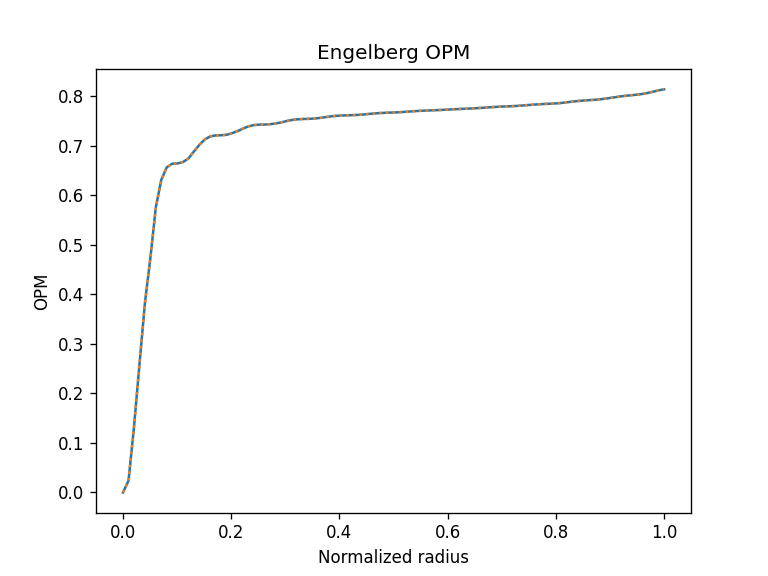

In [172]:
#Engelberg metric, check original paper for more detail 

center=(0,0)

parray = np.linspace(0, aperture_width/2, 100)

farray2 = [moe.metrics.Engelberg_OPM(Exy, p,  moe.metrics.encircled_energy(Exy, 1.01),1, wavelength, z = focal_length) for p in parray]
strehlr = moe.metrics.strehl_ratio(np.abs(Exy.screen[:,:,-1])**2, Exy, max([max(Exy.x), max(Exy.y)])*2, wavelength, focal_length, plot_MTF=True) 

fig = plt.figure() 

plt.plot(parray/(aperture_width/2), farray2)
plt.plot(parray/(aperture_width/2), strehlr*np.array(farray1), ':' )
#plt.ylim([0,1])
plt.xlabel("Normalized radius")
plt.ylabel("OPM")
plt.title("Engelberg OPM")



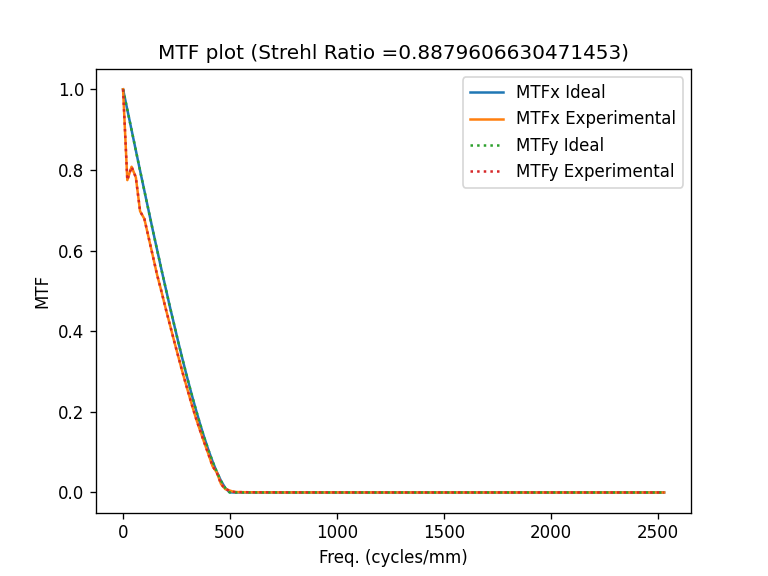

In [173]:
strehlr = moe.metrics.strehl_ratio(np.abs(Exy.screen[:,:,0])**2, screen, max([max(Exy.x), max(Exy.y)])*2, wavelength, focal_length, plot_MTF=True) 

Text(0.5, 1.0, 'Ensquared energy')

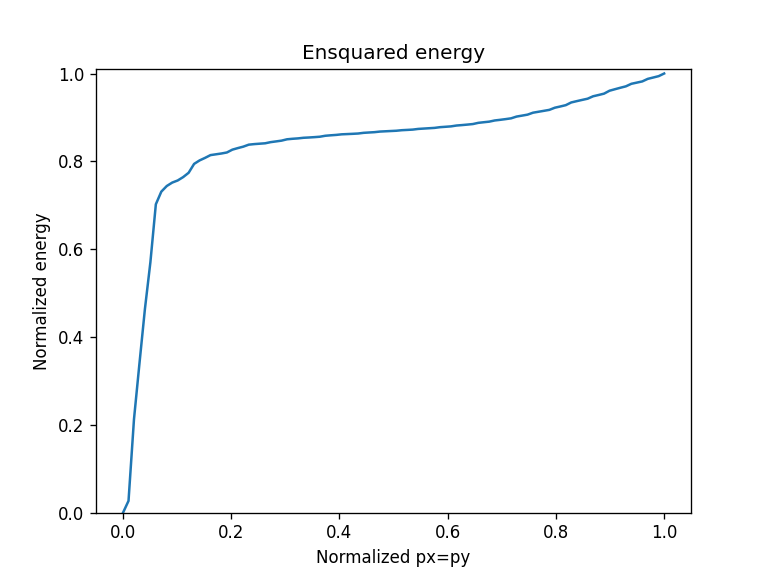

In [174]:
center=(0,0)

parray = np.linspace(0, aperture_width/2, 100)

enarray = [moe.metrics.ensquared_energy(Exy, p, p) for p in parray]
enmax = moe.metrics.ensquared_energy(Exy, 1,1)

fig = plt.figure() 

plt.plot(parray/(aperture_width/2), enarray/enmax)
plt.ylim([0,1.01])
plt.xlabel("Normalized px=py")
plt.ylabel("Normalized energy")
plt.title("Ensquared energy")

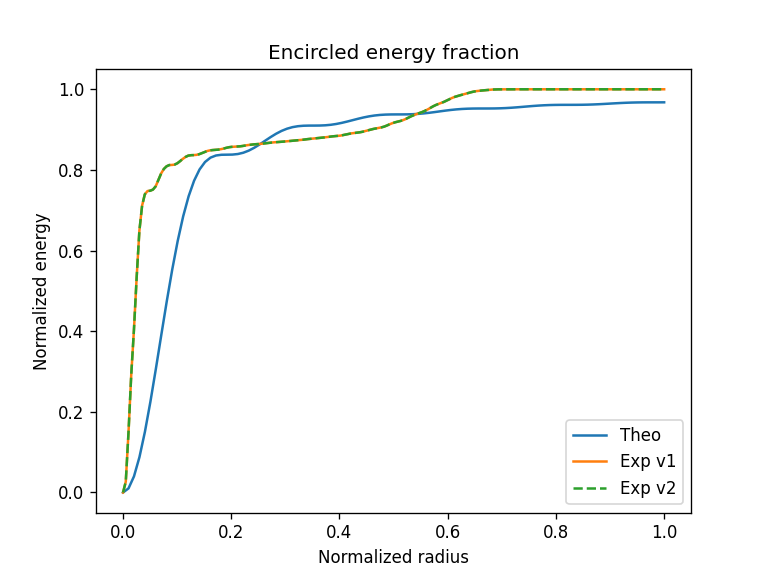

In [187]:
## RESULT TO BE CHECKED, MISMATCH MAYBE DUE TO DISTINCT DEFINITION OF RADIUS p ??

center=(0,0)

parray1 = np.linspace(0, aperture_width, 200)

enarray = [moe.metrics.encircled_energy(Exy, p) for p in parray1]
enmax = moe.metrics.encircled_energy(Exy, 1.01)


parray2 = np.linspace(0, aperture_width*10, 100)
enarray_theo = [moe.metrics.theoretical_encircled_energy(Exy, p) for p in parray2]
enmaxtheo = moe.metrics.theoretical_encircled_energy(Exy, 1.01)


enarray2 = [moe.metrics.encircled_energy(Exy, p) for p in parray1]
enmax2 = moe.metrics.encircled_energy(Exy, 1.01)


fig = plt.figure() 

plt.plot(parray2/parray2.max(), enarray_theo/enmaxtheo, label="Theo")
plt.plot(parray1/parray1.max(), enarray/enmax, label = "Exp v1")

plt.plot(parray1/parray1.max(), enarray2/enmax2 , '--', label ="Exp v2")

plt.xlabel("Normalized radius")
plt.ylabel("Normalized energy")
plt.title("Encircled energy fraction")

plt.legend()

#This is not exactly one, because other energy is lost to the square parts of the sensor 


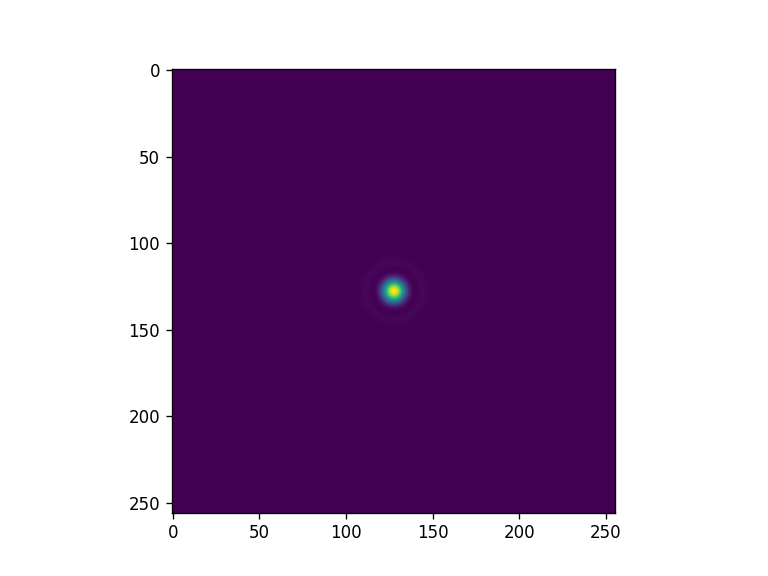

In [176]:
fig = plt.figure()
plt.imshow(np.abs(Exy.screen[:,:,-1])**2)

Picking up the last z propagated assumed to be the screen position


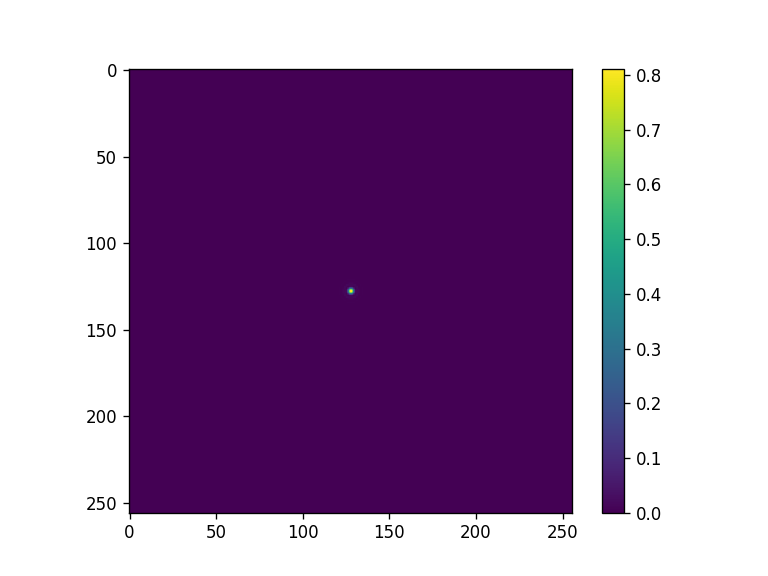

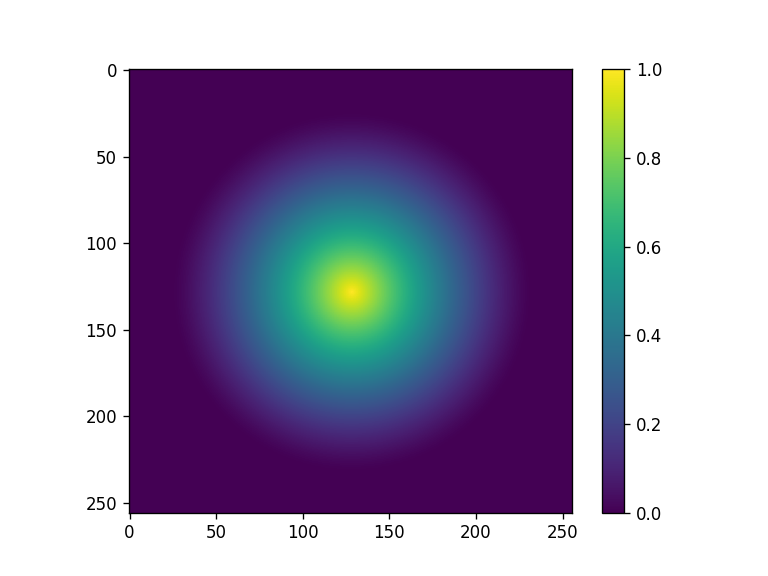

<Figure size 768x576 with 0 Axes>

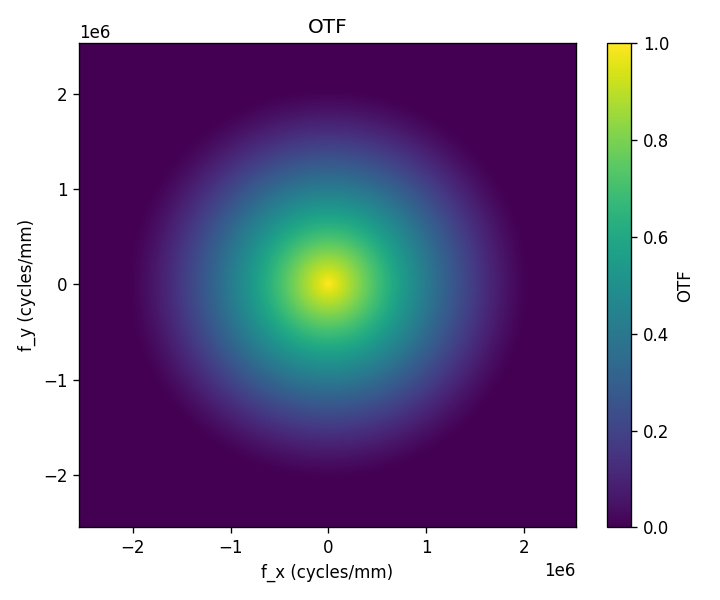

In [177]:
#Sanity check with theoretical Airy pattern MTF, 
# here the theoretical and calculated MTFs should give the same with unitary Strehl ratio

D = np.max(Exy.x)*2        

wavelength = 200e-9  # Wavelength in meters (e.g., 550 nm)

intensity_circular = intensity_theo_Airy(screen, D*2, wavelength, z=1)


fig = plt.figure() 
plt.imshow(intensity_circular  )
plt.colorbar()

OTF_circular = calculate_OTF(intensity_circular)


fig = plt.figure()
plt.imshow(np.abs(OTF_circular) )
plt.colorbar()

fig = plt.figure()

N = 512
dx = 10e-6  # pixel pitch in meters
dy = 10e-6


# Plot
plt.figure(figsize=(6, 5))
plt.imshow(np.abs(OTF_circular), extent=(np.min(Exy.fx), np.max(Exy.fx), np.min(Exy.fy), np.max(Exy.fy)),
           origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(label='OTF')
plt.xlabel('f_x (cycles/mm)')
plt.ylabel('f_y (cycles/mm)')
plt.title('OTF')
plt.tight_layout()
plt.show()

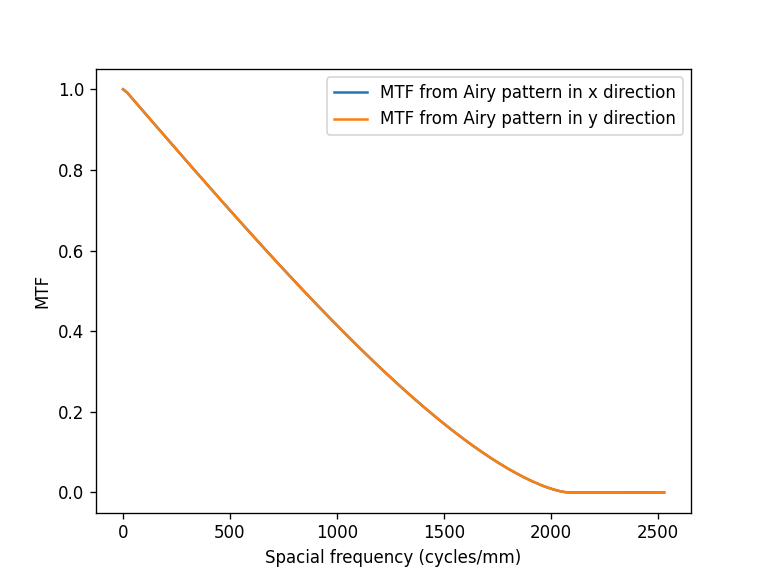

In [178]:
mtf, mtfx1, mtfy1 = moe.metrics.MTF_from_OTF(OTF_circular)


fx, fy = screen.fx*1e-3, screen.fy *1e-3

fig = plt.figure() 
plt.plot(fx[np.where(fx>=0)],  mtfx1, label="MTF from Airy pattern in x direction")
plt.plot(fy[np.where(fy>=0)],  mtfy1, label="MTF from Airy pattern in y direction")
plt.xlabel("Spacial frequency (cycles/mm)")
plt.ylabel("MTF")

plt.legend()


In [179]:


otf = moe.metrics.theoretical_ideal_OTF(screen, D*2, wavelength, screen.z[-1]) 

mtf, mtfx2, mtfy2 = moe.metrics.MTF_from_OTF(otf)

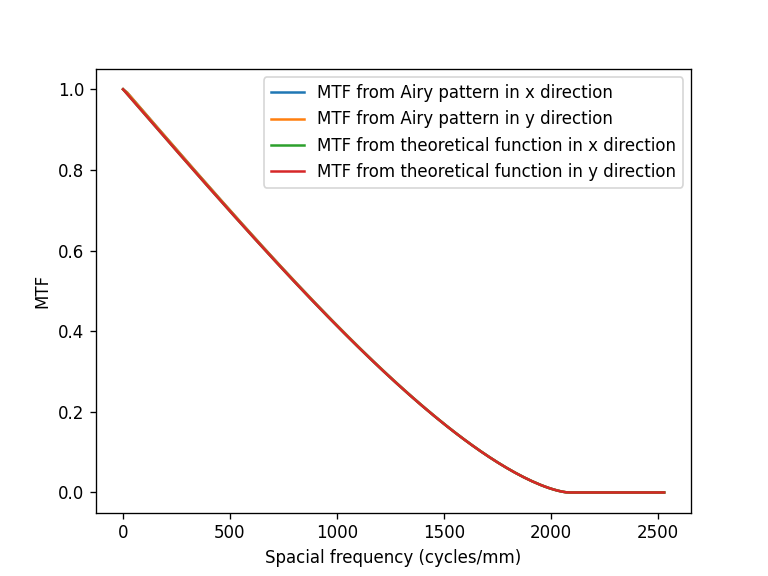

In [180]:
fx = screen.fx*1e-3
fy = screen.fy*1e-3

fig = plt.figure() 
plt.plot(fx[np.where(fx>=0)],  mtfx1, label="MTF from Airy pattern in x direction")
plt.plot(fy[np.where(fy>=0)],  mtfy1, label="MTF from Airy pattern in y direction")
plt.plot(fx[np.where(fx>=0)],  mtfx2, label="MTF from theoretical function in x direction")
plt.plot(fy[np.where(fy>=0)],  mtfy2, label="MTF from theoretical function in y direction")
plt.xlabel("Spacial frequency (cycles/mm)")
plt.ylabel("MTF")

plt.legend()

In [181]:
#This should give 1 

moe.metrics.strehl_ratio(intensity_circular, screen, D*2, wavelength, z = screen.z[-1])

np.float64(0.8138093632949268)

In [ ]:
def FOM_strehl(x, mask, screen, wavelength, mat): 

    import jax.numpy as np 
    
    diff = 1 - moe.metrics.strehl_ratio(np.abs(np.reshape(x, (len(screen.x), len(screen.y))))**2, screen, \
                                        np.max(screen.x) - np.min(screen.x), wavelength, z = screen.z[-1])

    return diff